### Concatenating Contacts Files

In [1]:
import os

# --- Configuration ---
BASE_DIR = "/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_file"

# UPDATE THIS if your 5ns chunks have a different number of frames!
FRAMES_PER_CHUNK = 2500 

FILE_LIST = [
    "contacts_low_res_50_to_55.out",
    "contacts_low_res_55_to_60.out",
    "contacts_low_res_60_to_65.out",
    "contacts_low_res_65_to_70.out",
    "contacts_low_res_70_to_75.out",
    "contacts_low_res_75_to_80.out",
    "contacts_low_res_80_to_85.out",
    "contacts_low_res_85_to_90.out",
    "contacts_low_res_90_to_95.out",
    "contacts_low_res_95_to_100.out"
]

OUTPUT_FILE = os.path.join("/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis", "contacts_low_res_50_to_100.txt") # BASE_DIR

def concatenate_and_sort():

    
    all_contacts = []
    current_offset = 0
    
    # 1. Read, offset, and store all data
    for filename in FILE_LIST:
        # Construct the full path to the file
        file_path = os.path.join(BASE_DIR, filename)
        
        if not os.path.exists(file_path):
            print(f"  -> WARNING: {filename} not found in {BASE_DIR}. Skipping.")
            continue
            
        print(f"Processing {filename} | Applying frame offset: +{current_offset}")
        
        with open(file_path, 'r') as in_f:
            for line in in_f:
                line = line.strip()
                if not line:
                    continue
                    
                parts = line.split()
                
                if len(parts) >= 7:
                    # Extract the water ID for sorting
                    water_id = int(parts[0])
                    
                    # Extract, offset, and update t1 and t2
                    t1 = int(parts[4]) + current_offset
                    t2 = int(parts[5]) + current_offset
                    
                    parts[4] = str(t1)
                    parts[5] = str(t2)
                    
                    new_line = " ".join(parts)
                    
                    # Append as a tuple: (water_id, t1, string_to_write)
                    all_contacts.append((water_id, t1, new_line))
        
        # Increase the offset for the next file
        current_offset += FRAMES_PER_CHUNK
        
    # 2. Sort the stored data
    print("\nSorting data by Water ID, then chronologically by entry time (t1)...")
    # Python's sort will automatically sort by the first item in the tuple (water_id), 
    # and use the second item (t1) as a tie-breaker
    all_contacts.sort(key=lambda item: (item[0], item[1]))
    
    # 3. Write out the sorted data
    print(f"Writing {len(all_contacts)} sorted contacts to {OUTPUT_FILE}...")
    with open(OUTPUT_FILE, 'w') as out_f:
        out_f.write("water_index x y z t1 t2 residence_fraction protein_site\n")
        
        for contact in all_contacts:
            # contact[2] is the fully offset string we saved
            out_f.write(contact[2] + "\n")
            
    print("Success! Sorted timeline saved.")

if __name__ == "__main__":
    concatenate_and_sort()

  -> WARNING: contacts_low_res_50_to_55.out not found in /Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_file. Skipping.
  -> WARNING: contacts_low_res_55_to_60.out not found in /Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_file. Skipping.
  -> WARNING: contacts_low_res_60_to_65.out not found in /Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_file. Skipping.
  -> WARNING: contacts_low_res_65_to_70.out not found in /Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_file. Skipping.
  -> WARNING: contacts_low_res_70_to_75.out not found in /Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_file. Skipping.
  -> WARNING: contacts_low_res_75_to_80.out not found in /Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_file. Skipping.
  -> WARNING: contacts_low_res_80_to_85.out not found in /Users/kanishkkondaka/Des

In [ ]:
import mdtraj as md
import numpy as np
import os

# 1. File paths
pdb_file = '/Users/kanishkkondaka/Desktop/margaret_files/0F.pdb_fittedto55all.pdb'
oex_pdb_file = '/Users/kanishkkondaka/Desktop/margaret_files/start_Cl_sim_new_unit_cell.pdb'

# Load main structure
t = md.load(pdb_file)
tp = t.topology

# Load OEX reference PDB if available
t_oex = None
tp_oex = None
if os.path.exists(oex_pdb_file):
    t_oex = md.load(oex_pdb_file)
    tp_oex = t_oex.topology
    print(f"Loaded secondary OEX reference structure: {oex_pdb_file}")
else:
    print(f"Notice: Could not locate {oex_pdb_file}. Checking OEX in main structure only.")

# 2. Extract Chain G water oxygens (specifically including 'OOO')
w_i = [
    atom.index for atom in tp.atoms 
    if (atom.residue.is_water or atom.residue.name == 'OOO') 
    and atom.element.symbol == 'O' 
    and atom.residue.chain.chain_id == 'G'
]

# 3. Extract protein heavy atoms + cofactors/ligands across the main structure
heavy_res = {
    'OEX', 'PHO', 'SQD', 'HEM', 'LHG', 'LMG', 'PL9', 'BCR', 
    'CLA', 'DGD', 'STE', 'FE2', 'CL1', 'WON', 'WTW', 'WTH', 'WFO'
}

pl_i = [
    atom.index for atom in tp.atoms 
    if (atom.residue.is_protein or atom.residue.name in heavy_res) 
    and atom.element.symbol != 'H'
]
pl_i_np = np.array(pl_i)

# Identify OEX atom indices in main topology
oex_indices_main = set([atom.index for atom in tp.atoms if atom.residue.name == 'OEX'])

# Identify OEX atom indices in secondary PDB (if loaded)
oex_atoms_oex_pdb = []
if tp_oex is not None:
    oex_atoms_oex_pdb = [atom.index for atom in tp_oex.atoms if atom.residue.name == 'OEX']

print("=" * 70)
print(f"Total Chain G waters found: {len(w_i)}")
print(f"Total OEX atoms in main structure (0F): {len(oex_indices_main)}")
if tp_oex is not None:
    print(f"Total OEX atoms in start_Cl_sim_new_unit_cell.pdb: {len(oex_atoms_oex_pdb)}")
print("=" * 70 + "\n")

# 4. Distance calculation parameters
thresh = 0.3  # 0.3 nm (3.0 Å)
ap = np.zeros((len(pl_i), 2))
outlist = []

print("Calculating reference contacts and scanning for OEX matches...\n")

# 5. Distance calculation for frame 0
for ei in w_i:
    atom = tp.atom(ei)
    res_id = atom.residue.resSeq  # Extract the PDB Residue Sequence Number
    
    ap[:, 0] = ei
    ap[:, 1] = pl_i
    
    ds = md.compute_distances(t, ap, periodic=True)
    dst = ds[0] < thresh 
    
    # Save if water contacts at least 3 heavy non-hydrogen atoms
    if np.sum(dst) >= 3:
        it = pl_i_np[dst].tolist()
        xyzm = t.xyz[0, ei] * 10.0  # Convert nm to Å
        
        # Format: resid, X, Y, Z, t_start, t_end, residence_time, [contact_heavy_atoms]
        outlist.append(f"{res_id} {xyzm[0]:.5f} {xyzm[1]:.5f} {xyzm[2]:.5f} 0 0 0.0 {it}")
        
        # Check if any contacting heavy atoms in 0F belong to OEX
        oex_contacts_main = [idx for idx in it if idx in oex_indices_main]
        if oex_contacts_main:
            print(f"*** MATCH FOUND in 0F ***")
            print(f" -> Water ResID {res_id:4d} (Index {ei}) contacts {len(oex_contacts_main)} OEX atom(s) in main PDB: {oex_contacts_main}")

    # Direct spatial distance check against OEX atoms in start_Cl_sim_new_unit_cell.pdb
    if t_oex is not None and len(oex_atoms_oex_pdb) > 0:
        water_xyz = t.xyz[0, ei]
        for o_idx in oex_atoms_oex_pdb:
            oex_xyz = t_oex.xyz[0, o_idx]
            dist_nm = np.linalg.norm(water_xyz - oex_xyz)
            
            if dist_nm < thresh:
                dist_ang = dist_nm * 10.0
                oex_atom_obj = tp_oex.atom(o_idx)
                print(f"*** SPECIAL MATCH in start_Cl_sim_new_unit_cell.pdb ***")
                print(f" -> Water ResID {res_id:4d} (Index {ei}) is {dist_ang:.2f} Å from OEX atom {o_idx} ({oex_atom_obj.name})")

# 6. Save reference contacts
out_file = '/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/reference_contacts.txt'
with open(out_file, 'w') as f:
    for line in outlist:
        f.write(line + "\n")

print("\n" + "=" * 70)
print(f"Successfully saved {len(outlist)} reference contacts to {out_file}")

### Takes in Water ID

In [ ]:
import os

# --- Configuration ---
CONTACTS_FILE = "/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_low_res_50_to_100.txt"
WATER_ID_TO_EXTRACT = "434989" # Change this to your target Water ID
OUTPUT_PDB = f"/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/water_{WATER_ID_TO_EXTRACT}_trajectory.pdb"

def calc_b_factor(t1, t2):
    """
    Easily editable formula for the B-factor column.
    Currently set to t2 - t1 (the duration of the contact).
    """
    return float(t2 - t1)

def extract_water_trajectory(contacts_file, target_water_id, output_filename):
    target_water_str = str(target_water_id)
    occurrences = []
    
    print(f"Scanning {contacts_file} for Water ID {target_water_str}...")
    
    # 1. Read and extract data
    with open(contacts_file, 'r') as f:
        for line in f:
            # Skip any header lines
            if not line[0].isdigit():
                continue
                
            parts = line.strip().split()
            if len(parts) >= 6:
                w_idx = parts[0]
                
                # Check if this line belongs to our target water
                if w_idx == target_water_str:
                    x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                    t1, t2 = int(parts[4]), int(parts[5])
                    occurrences.append((t1, t2, x, y, z))
                    
    if not occurrences:
        print(f"No data found for Water ID {target_water_str}.")
        return

    # 2. Sort chronologically by t1
    occurrences.sort(key=lambda item: item[0])
    
    # 3. Write to PDB
    print(f"Writing {len(occurrences)} frames to {output_filename}...")
    with open(output_filename, 'w') as out_f:
        for idx, (t1, t2, x, y, z) in enumerate(occurrences, start=1):
            
            # Calculate B-factor using the custom function
            b_factor = calc_b_factor(t1, t2)
            
            # Keep serial number within PDB limits (max 99999)
            safe_serial = idx % 100000
            
            # Write the HETATM record
            out_f.write(
                f"HETATM{safe_serial:5d}  O   HOH W{safe_serial:4d}    "
                f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00{b_factor:6.2f}           O\n"
            )
        out_f.write("END\n")
        
    print("Done!")

if __name__ == "__main__":
    extract_water_trajectory(CONTACTS_FILE, WATER_ID_TO_EXTRACT, OUTPUT_PDB)

Scanning /Users/kanishkkondaka/Desktop/margaret_files/contacts_margaret_50_to_100.txt for Water ID 434989...
Writing 177 frames to /Users/kanishkkondaka/Desktop/margaret_files/water_434989_trajectory.pdb...
Done!


## 3D View


W19: (711, 3)
W20: (648, 3)


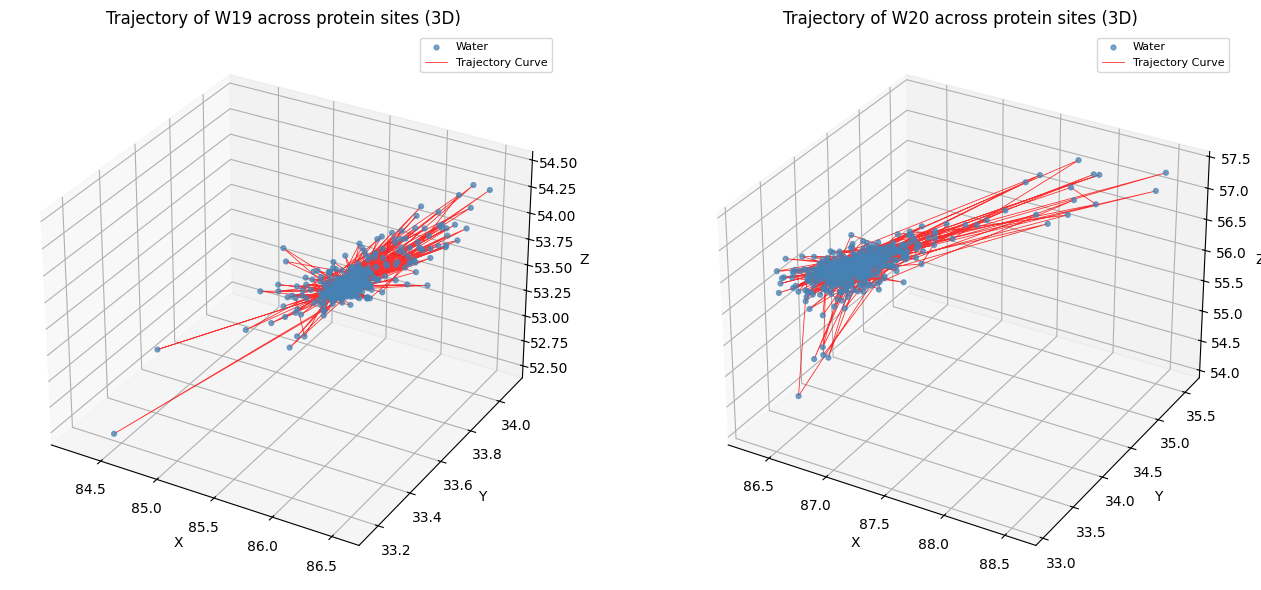

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def coords_from_pdb(pdb_path, atom_name=None):
    """Grab every atom's coordinates from a PDB, in file order."""
    coords = []
    with open(pdb_path) as f:
        for line in f:
            if line.startswith(('ATOM', 'HETATM')):
                name = line[12:16].strip()
                if atom_name is None or name == atom_name:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append((x, y, z))
    return np.array(coords)


def plot_water_trajectory(coords, water_label, ax):
    x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]
    ax.scatter(x, y, z, c='steelblue', s=12, alpha=0.7, label='Water')
    ax.plot(x, y, z, c='red', linewidth=0.6, alpha=0.8, label='Trajectory Curve')
    ax.set_title(f'Trajectory of {water_label} across protein sites (3D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend(loc='upper right', fontsize=8)


coords_W19 = coords_from_pdb('/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/water_pdbs/O4/W19.pdb')
coords_W20 = coords_from_pdb('/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/water_pdbs/O4/W20.pdb')

print('W19:', coords_W19.shape)   # should be (n_frames, 3)
print('W20:', coords_W20.shape)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_water_trajectory(coords_W19, 'W19', ax1)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plot_water_trajectory(coords_W20, 'W20', ax2)
plt.tight_layout()
plt.savefig('/Users/kanishkkondaka/Downloads/W19_W20_low_restrajectories.png', dpi=150)
plt.show()

## Walk Animation

W19: (711, 3)
W20: (648, 3)


saved W19_W20_walk.gif


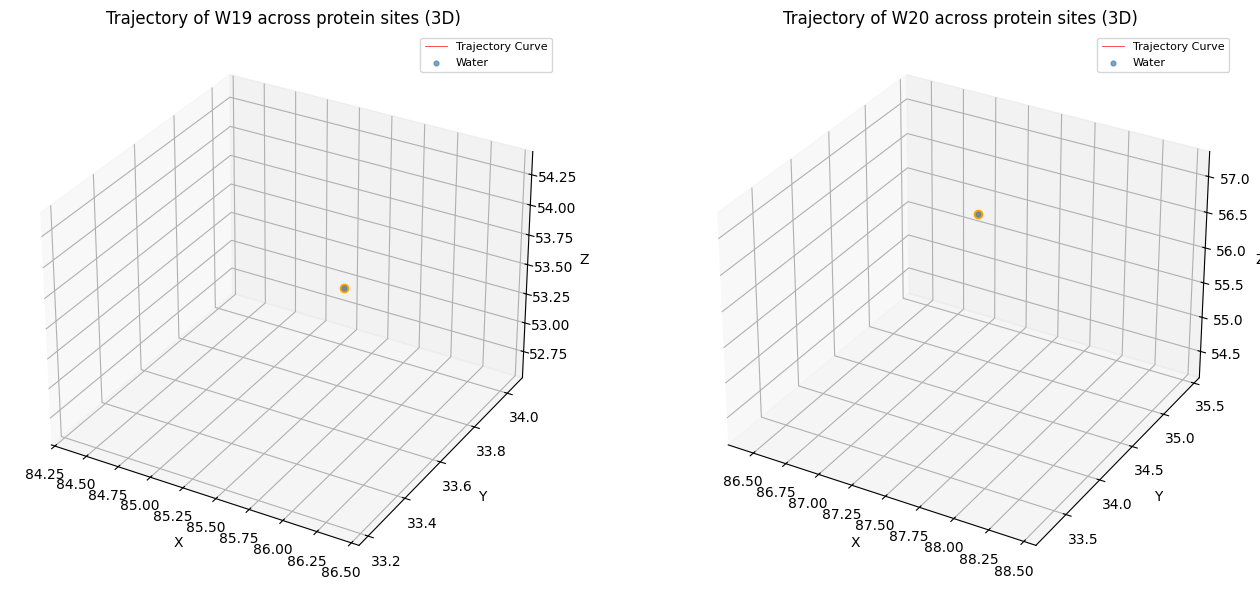

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def coords_from_pdb(pdb_path, atom_name=None):
    """Grab every atom's coordinates from a PDB, in file order."""
    coords = []
    with open(pdb_path) as f:
        for line in f:
            if line.startswith(('ATOM', 'HETATM')):
                name = line[12:16].strip()
                if atom_name is None or name == atom_name:
                    x = float(line[30:38])
                    y = float(line[38:46])
                    z = float(line[46:54])
                    coords.append((x, y, z))
    return np.array(coords)


coords_W19 = coords_from_pdb('/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/water_pdbs/O4/W19.pdb')
coords_W20 = coords_from_pdb('/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/water_pdbs/O4/W20.pdb')

print('W19:', coords_W19.shape)
print('W20:', coords_W20.shape)


def setup_axis(ax, coords, water_label):
    """Fix the axis limits/labels up front so they don't jump around as the trail grows."""
    ax.set_xlim(coords[:, 0].min(), coords[:, 0].max())
    ax.set_ylim(coords[:, 1].min(), coords[:, 1].max())
    ax.set_zlim(coords[:, 2].min(), coords[:, 2].max())
    ax.set_title(f'Trajectory of {water_label} across protein sites (3D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
setup_axis(ax1, coords_W19, 'W19')
setup_axis(ax2, coords_W20, 'W20')

# artists we'll update each frame: the growing red line, all-visited dots, and the current position
line1, = ax1.plot([], [], [], c='red', linewidth=0.6, alpha=0.8, label='Trajectory Curve')
dots1 = ax1.scatter([], [], [], c='steelblue', s=12, alpha=0.7, label='Water')
head1, = ax1.plot([], [], [], 'o', c='orange', markersize=6)

line2, = ax2.plot([], [], [], c='red', linewidth=0.6, alpha=0.8, label='Trajectory Curve')
dots2 = ax2.scatter([], [], [], c='steelblue', s=12, alpha=0.7, label='Water')
head2, = ax2.plot([], [], [], 'o', c='orange', markersize=6)

ax1.legend(loc='upper right', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

# animate up to the length of the longer trajectory
n_frames = max(len(coords_W19), len(coords_W20))

def update(i):
    for coords, line, dots, head in [
        (coords_W19, line1, dots1, head1),
        (coords_W20, line2, dots2, head2),
    ]:
        k = min(i + 1, len(coords))   # clamp for the shorter trajectory
        sub = coords[:k]
        line.set_data(sub[:, 0], sub[:, 1])
        line.set_3d_properties(sub[:, 2])
        dots._offsets3d = (sub[:, 0], sub[:, 1], sub[:, 2])
        head.set_data([sub[-1, 0]], [sub[-1, 1]])
        head.set_3d_properties([sub[-1, 2]])
    return line1, dots1, head1, line2, dots2, head2

anim = FuncAnimation(fig, update, frames=n_frames, interval=50, blit=False)

plt.tight_layout()
anim.save('/Users/kanishkkondaka/Downloads/W19_W20_low_res_walk.gif', writer=PillowWriter(fps=20))
print('saved W19_W20_walk.gif')

### Entry/Exit 


Reading reference PDB: /Users/kanishkkondaka/Desktop/margaret_files/0F.pdb_fittedto55all.pdb...
Parsing /Users/kanishkkondaka/Desktop/margaret_files/contacts_margaret_50_to_100.txt for entry and exit coordinates...
Performing nearest neighbor matching for Entry coordinates (4.0 Å cutoff)...
Performing nearest neighbor matching for Exit coordinates (4.0 Å cutoff)...


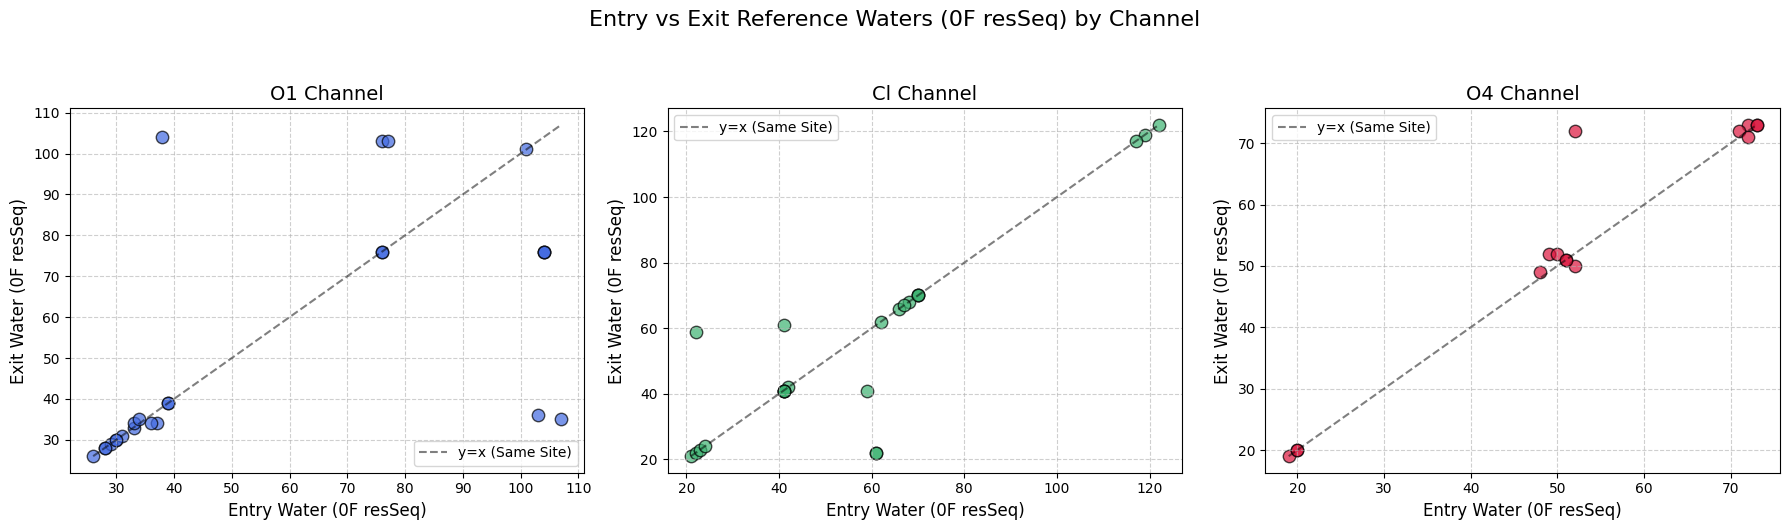

In [ ]:
import math
import matplotlib.pyplot as plt
from collections import defaultdict

# --- Configuration ---
REFERENCE_PDB = "/Users/kanishkkondaka/Desktop/margaret_files/0F.pdb_fittedto55all.pdb"
CONTACTS_FILE = "/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_low_res_50_to_100.txt"

TARGETS = {
    "O1": [26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 76, 77, 101, 102, 103, 104, 105, 106, 107, 108],
    "Cl": [59, 60, 66, 67, 68, 69, 70, 21, 22, 23, 24, 25, 61, 62, 40, 41, 42, 150, 117, 119, 121, 122, 150],
    "O4": [19, 20, 48, 49, 50, 51, 52, 53, 71, 72, 73]
}

def calc_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2 + (p1[2]-p2[2])**2)

# --- 1. Load Reference Waters ---
print(f"Reading reference PDB: {REFERENCE_PDB}...")
ref_waters = {}
with open(REFERENCE_PDB, 'r') as f:
    for line in f:
        if line.startswith("HETATM") or line.startswith("ATOM"):
            chain = line[21].strip()
            res_name = line[17:20].strip()
            if chain == 'G' and res_name == 'OOO':
                try:
                    resSeq = int(line[22:26].strip())
                    x = float(line[30:38].strip())
                    y = float(line[38:46].strip())
                    z = float(line[46:54].strip())
                    
                    for channel, res_list in TARGETS.items():
                        if resSeq in res_list:
                            ref_waters[resSeq] = {'coords': (x, y, z), 'channel': channel}
                            break
                except ValueError:
                    pass

# --- 2. Extract First (Entry) and Last (Exit) Coordinates ---
md_bounds = defaultdict(lambda: {
    'min_t1': float('inf'), 'entry_coords': None,
    'max_t2': float('-inf'), 'exit_coords': None
})

print(f"Parsing {CONTACTS_FILE} for entry and exit coordinates...")
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if not line[0].isdigit():
            continue
            
        parts = line.strip().split()
        if len(parts) >= 6:
            w_idx = parts[0]
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            t1, t2 = int(parts[4]), int(parts[5])
            
            # Update Entry (lowest t1)
            if t1 < md_bounds[w_idx]['min_t1']:
                md_bounds[w_idx]['min_t1'] = t1
                md_bounds[w_idx]['entry_coords'] = (x, y, z)
                
            # Update Exit (highest t2)
            if t2 > md_bounds[w_idx]['max_t2']:
                md_bounds[w_idx]['max_t2'] = t2
                md_bounds[w_idx]['exit_coords'] = (x, y, z)

# Separate coordinates for processing
all_entry_coords = {w_idx: data['entry_coords'] for w_idx, data in md_bounds.items() if data['entry_coords']}
all_exit_coords = {w_idx: data['exit_coords'] for w_idx, data in md_bounds.items() if data['exit_coords']}

# --- 3. The Nearest Neighbor Matching Algorithm ---
def nearest_match(ref_dict, target_coords_dict, distance_cutoff=4.0):
    """
    Matches MD coordinates to the absolute closest Reference water,
    provided the distance is less than or equal to the distance_cutoff.
    Repeating is allowed (many-to-one matching).
    """
    matches = {}
    for md_idx, coords in target_coords_dict.items():
        min_dist = float('inf')
        best_resSeq = None
        
        # Check distance against every reference water to find the closest one
        for resSeq, ref_data in ref_dict.items():
            dist = calc_distance(ref_data['coords'], coords)
            if dist < min_dist:
                min_dist = dist
                best_resSeq = resSeq
                
        # Only save the match if it falls within the 4.0 Å threshold
        if best_resSeq is not None and min_dist <= distance_cutoff:
            matches[md_idx] = {'resSeq': best_resSeq, 'dist': min_dist}
        
    return matches

# --- 4. Apply Matching Algorithm ---
print("Performing nearest neighbor matching for Entry coordinates (4.0 Å cutoff)...")
entry_matches = nearest_match(ref_waters, all_entry_coords, distance_cutoff=4.0)

print("Performing nearest neighbor matching for Exit coordinates (4.0 Å cutoff)...")
# To track the flow of the exact same water molecules, we map the exit coordinates 
# of the specific MD waters that were successfully matched during entry.
matched_exit_coords = {md_idx: all_exit_coords[md_idx] for md_idx in entry_matches.keys()}
exit_matches = nearest_match(ref_waters, matched_exit_coords, distance_cutoff=4.0)

# --- 5. Group Data for Plotting ---
plot_data = {channel: {'entry_res': [], 'exit_res': []} for channel in TARGETS.keys()}

for md_idx in exit_matches.keys():
    # Extract the resSeq ID from the new dictionary structure
    entry_resSeq = entry_matches[md_idx]['resSeq']
    exit_resSeq = exit_matches[md_idx]['resSeq']
    
    # Group by the channel of the Entry reference water
    channel = ref_waters[entry_resSeq]['channel']
    
    plot_data[channel]['entry_res'].append(entry_resSeq)
    plot_data[channel]['exit_res'].append(exit_resSeq)

# --- 6. Generate Scatter Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Entry vs Exit Reference Waters (0F resSeq) by Channel", fontsize=16, y=1.05)

colors = {'O1': 'royalblue', 'Cl': 'mediumseagreen', 'O4': 'crimson'}

for ax, (channel, data) in zip(axes, plot_data.items()):
    # Scatter plot
    ax.scatter(data['entry_res'], data['exit_res'], 
               c=colors[channel], alpha=0.7, edgecolors='k', s=80)
    
    # Formatting
    ax.set_title(f"{channel} Channel", fontsize=14)
    ax.set_xlabel("Entry Water (0F resSeq)", fontsize=12)
    ax.set_ylabel("Exit Water (0F resSeq)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add a y=x diagonal line 
    all_res = data['entry_res'] + data['exit_res']
    if all_res:
        min_val, max_val = min(all_res), max(all_res)
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='y=x (Same Site)')
        ax.legend()

plt.tight_layout()
plt.show()

### Combine Graphs

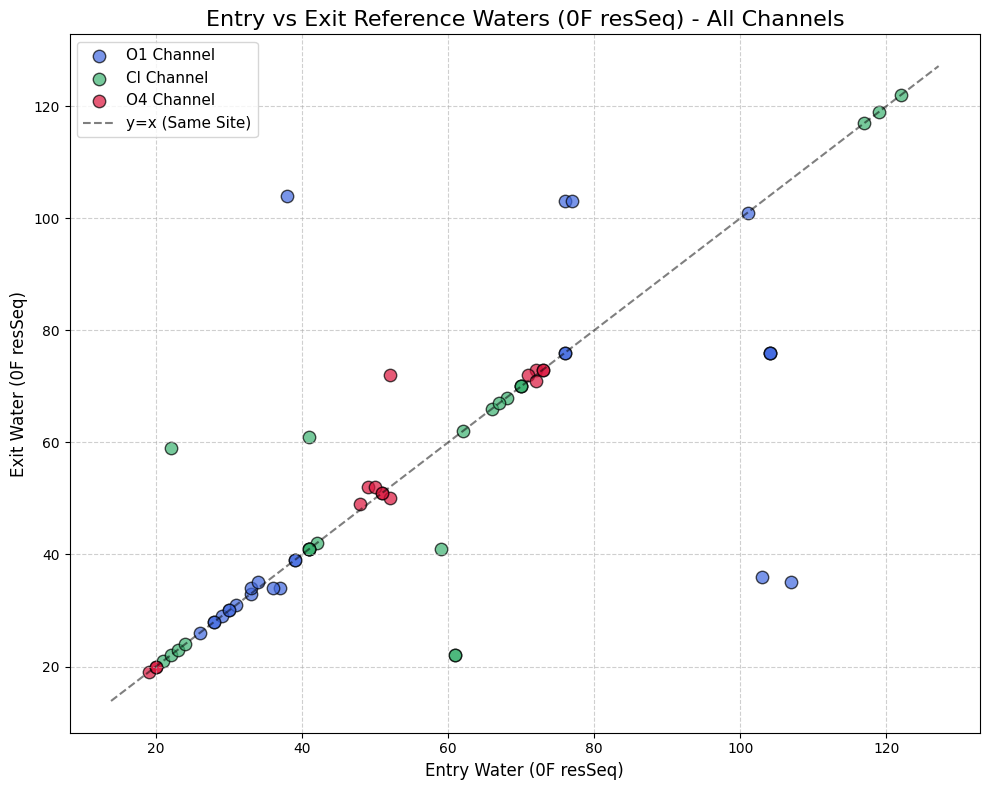

In [ ]:
# --- 6. Generate Combined Scatter Plot ---
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title("Entry vs Exit Reference Waters (0F resSeq) - All Channels", fontsize=16)

colors = {'O1': 'royalblue', 'Cl': 'mediumseagreen', 'O4': 'crimson'}
all_res_global = [] # Store all coordinates to draw an accurate y=x reference line

for channel, data in plot_data.items():
    if data['entry_res']:
        # Scatter plot for each channel on the SAME axes
        ax.scatter(data['entry_res'], data['exit_res'], 
                   c=colors[channel], alpha=0.7, edgecolors='k', s=80, label=f"{channel} Channel")
        
        # Accumulate all values to calculate the min/max bounds later
        all_res_global.extend(data['entry_res'] + data['exit_res'])

# Formatting the combined plot
ax.set_xlabel("Entry Water (0F resSeq)", fontsize=12)
ax.set_ylabel("Exit Water (0F resSeq)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Add a single y=x diagonal line representing identical entry/exit sites
if all_res_global:
    min_val, max_val = min(all_res_global), max(all_res_global)
    padding = (max_val - min_val) * 0.05 if max_val != min_val else 5
    ax.plot([min_val - padding, max_val + padding], 
            [min_val - padding, max_val + padding], 
            'k--', alpha=0.5, label='y=x (Same Site)')

# Display the legend to differentiate the channels
ax.legend(fontsize=11, loc="best")

plt.tight_layout()
plt.show()

### Single Graph

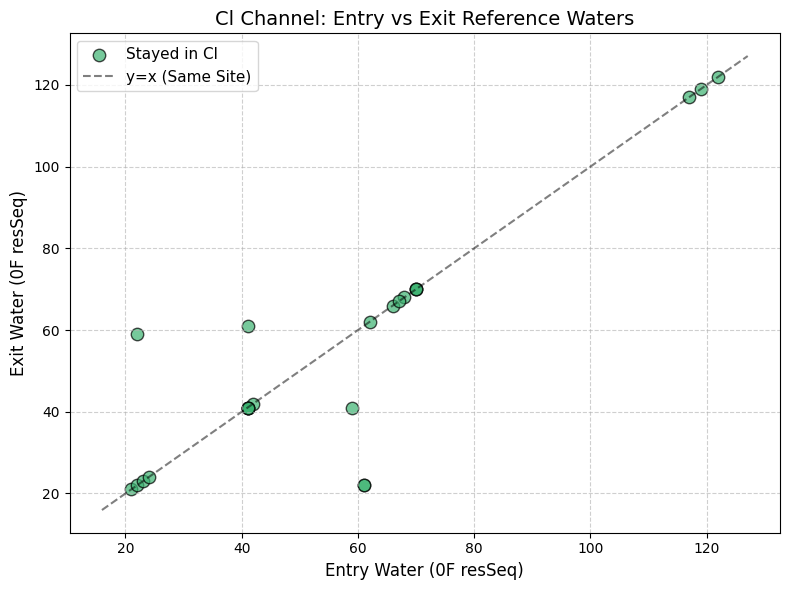

In [ ]:
# Change this variable to "O1", "Cl", or "O4" to view a different channel
CHANNEL_TO_PLOT = "Cl" 

# --- 6. Generate Single Channel Scatter Plot ---
if CHANNEL_TO_PLOT not in plot_data:
    print(f"Error: '{CHANNEL_TO_PLOT}' is not a valid channel. Please choose from {list(plot_data.keys())}.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    data = plot_data[CHANNEL_TO_PLOT]
    colors = {'O1': 'royalblue', 'Cl': 'mediumseagreen', 'O4': 'crimson'}
    
    if not data['entry_res']:
        print(f"No matching data found for the {CHANNEL_TO_PLOT} channel.")
    else:
        # --- NEW: Group points by their Exit Channel ---
        stay_x, stay_y = [], []
        crossover_data = defaultdict(lambda: {'x': [], 'y': []})
        
        for en_res, ex_res in zip(data['entry_res'], data['exit_res']):
            # Look up the channel the exit water belongs to
            exit_channel = ref_waters[ex_res]['channel']
            
            if exit_channel == CHANNEL_TO_PLOT:
                stay_x.append(en_res)
                stay_y.append(ex_res)
            else:
                crossover_data[exit_channel]['x'].append(en_res)
                crossover_data[exit_channel]['y'].append(ex_res)
        
        # --- Plot 1: Waters that stayed in the channel ---
        if stay_x:
            ax.scatter(stay_x, stay_y, 
                       c=colors[CHANNEL_TO_PLOT], alpha=0.7, edgecolors='k', s=80, 
                       label=f"Stayed in {CHANNEL_TO_PLOT}")
        
        # --- Plot 2: Waters that crossed over ---
        for dest_chan, coords in crossover_data.items():
            ax.scatter(coords['x'], coords['y'], 
                       c=colors.get(dest_chan, 'orange'), marker='^', alpha=0.9, edgecolors='k', s=100, 
                       label=f"Crossed to {dest_chan}")
        
        # Formatting
        ax.set_title(f"{CHANNEL_TO_PLOT} Channel: Entry vs Exit Reference Waters", fontsize=14)
        ax.set_xlabel("Entry Water (0F resSeq)", fontsize=12)
        ax.set_ylabel("Exit Water (0F resSeq)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Add a y=x diagonal line 
        all_res = data['entry_res'] + data['exit_res']
        if all_res:
            min_val, max_val = min(all_res), max(all_res)
            
            # Extend the line slightly past the min/max values for better visibility
            padding = (max_val - min_val) * 0.05 if max_val != min_val else 5
            ax.plot([min_val - padding, max_val + padding], 
                    [min_val - padding, max_val + padding], 
                    'k--', alpha=0.5, label='y=x (Same Site)')
            
        ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# 1. Dynamically extract all unique channels present in the entry matches
all_channels = sorted(set(
    ref_waters[entry_matches[md_idx]['resSeq']]['channel'] 
    for md_idx in exit_matches.keys() 
    if entry_matches[md_idx]['resSeq'] in ref_waters
))

# 2. Iterate through every channel automatically
for channel in all_channels:
    print(f"\n--- Tracking Data for Channel: {channel} ---")
    print(f"{'MD Water ID':<15} | {'Entry resSeq':<12} | {'Entry Dist (Å)':<15} | {'Exit resSeq':<12} | {'Exit Dist (Å)':<15}")
    print("-" * 79)
    
    for md_idx in exit_matches.keys():
        entry_resSeq = entry_matches[md_idx]['resSeq']
        
        # Check if the current water's entry matches this loop's channel
        if ref_waters[entry_resSeq]['channel'] == channel:
            entry_dist = entry_matches[md_idx]['dist']
            exit_resSeq = exit_matches[md_idx]['resSeq']
            exit_dist = exit_matches[md_idx]['dist']
            
            print(f"{md_idx:<15} | {entry_resSeq:<12} | {entry_dist:<15.3f} | {exit_resSeq:<12} | {exit_dist:<15.3f}")


--- Tracking Data for Channel: Cl ---
MD Water ID     | Entry resSeq | Entry Dist (Å)  | Exit resSeq  | Exit Dist (Å)  
-------------------------------------------------------------------------------
411475          | 41           | 2.699           | 41           | 1.595          
411544          | 70           | 2.878           | 70           | 3.306          
412201          | 70           | 1.682           | 70           | 1.849          
412726          | 69           | 1.388           | 68           | 1.182          
413008          | 119          | 1.538           | 119          | 0.393          
434875          | 21           | 0.374           | 21           | 0.392          
434878          | 22           | 0.421           | 22           | 2.983          
434881          | 61           | 1.728           | 22           | 0.255          
434884          | 21           | 2.965           | 22           | 0.516          
434887          | 23           | 0.784           | 23        

### Radius of Gyration

In [ ]:
import numpy as np
from collections import defaultdict

water_trajectory_coords = defaultdict(list)

print(f"Scanning {CONTACTS_FILE} to calculate trajectory Radius of Gyration...")
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if not line[0].isdigit():
            continue
            
        parts = line.strip().split()
        if len(parts) >= 4:
            w_idx = parts[0]
            
            # Only store coordinates for waters that successfully matched
            if w_idx in exit_matches:
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                water_trajectory_coords[w_idx].append([x, y, z])

# Calculate the Trajectory Rg (RMS deviation from centroid)
water_rg = {}
for w_idx, coords in water_trajectory_coords.items():
    pts = np.array(coords)
    
    if len(pts) > 0:
        centroid = pts.mean(axis=0)
        rg = np.sqrt(np.mean(np.sum((pts - centroid)**2, axis=1)))
        water_rg[w_idx] = rg
    else:
        water_rg[w_idx] = 0.0

print("water_rg successfully calculated and saved to memory!")

Scanning /Users/kanishkkondaka/Desktop/margaret_files/contacts_margaret_50_to_100.txt to calculate trajectory Radius of Gyration...
water_rg successfully calculated and saved to memory!


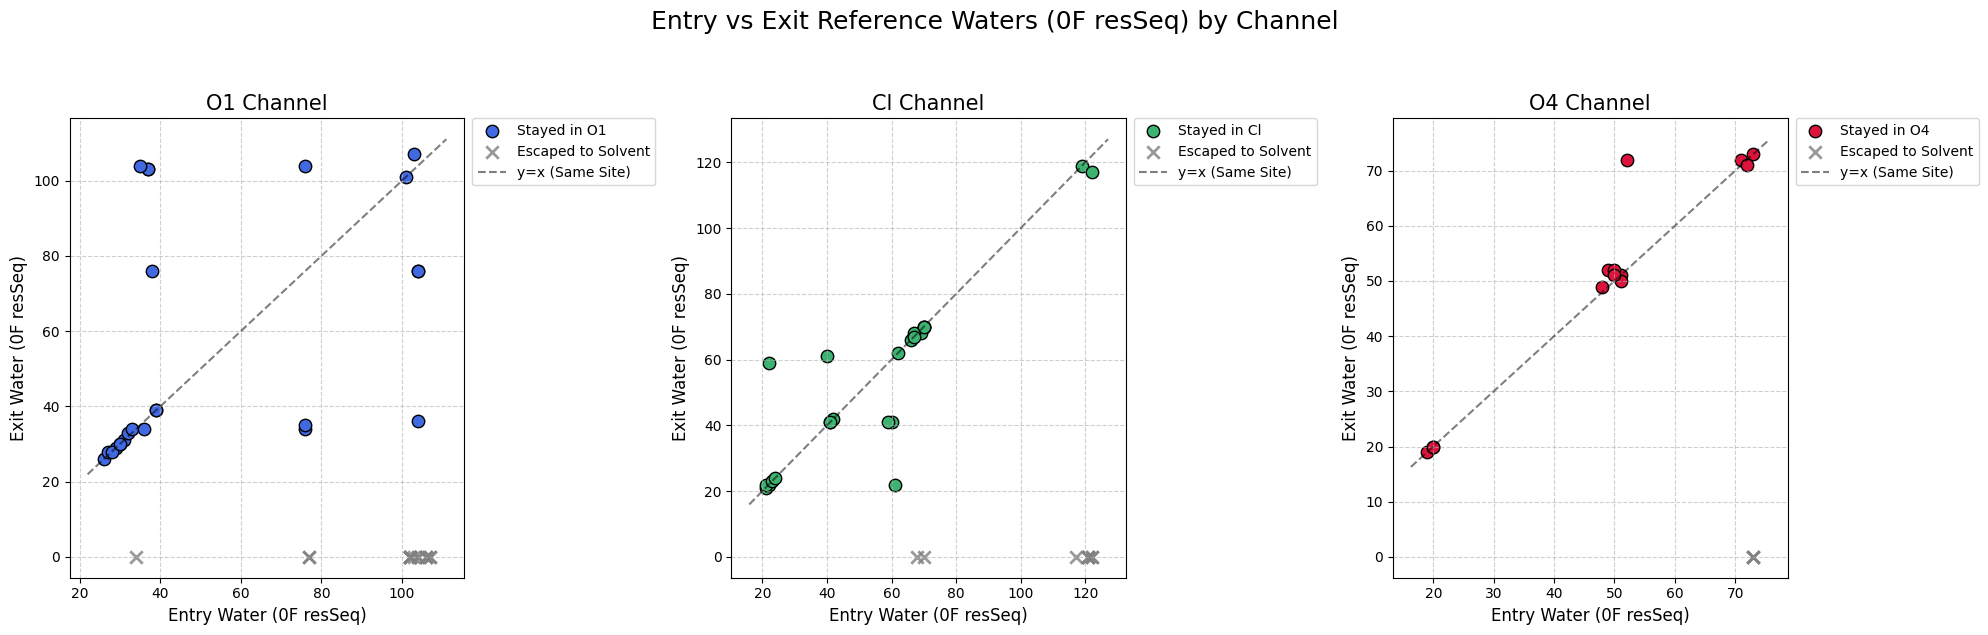

In [ ]:
import matplotlib.pyplot as plt
from collections import defaultdict

# --- 1. Setup Figure ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Entry vs Exit Reference Waters (0F resSeq) by Channel", fontsize=18, y=1.05)

colors = {'O1': 'royalblue', 'Cl': 'mediumseagreen', 'O4': 'crimson'}
channels_to_plot = ["O1", "Cl", "O4"]

# --- 2. Iterate and Plot Each Channel ---
for ax, current_channel in zip(axes, channels_to_plot):
    # Dictionaries to separate low Rg vs high Rg data
    stay_data = {'x': [], 'y': [], 'high_x': [], 'high_y': []}
    escaped_data = {'x': [], 'y': [], 'high_x': [], 'high_y': []} # Escaped bucket
    cross_data = defaultdict(lambda: {'x': [], 'y': [], 'high_x': [], 'high_y': []})
    
    all_x = []
    all_y = []
    
    # Categorize the data for the current channel
    for md_idx in exit_matches.keys():
        entry_res = entry_matches[md_idx]['resSeq']
        exit_res = exit_matches[md_idx]['resSeq']
        entry_channel = ref_waters[entry_res]['channel']
        
        # Only process waters that entered through the current subplot's channel
        if entry_channel == current_channel:
            
            # Safely handle the "0" ID for escaped waters
            if exit_res == 0:
                exit_channel = "Escaped"
            else:
                exit_channel = ref_waters[exit_res]['channel']
                
            rg_val = water_rg.get(md_idx, 0.0)
            is_high_rg = rg_val > 5.0
            
            all_x.append(entry_res)
            all_y.append(exit_res)
            
            # Bucket 1: Stayed in the same channel
            if exit_channel == current_channel:
                if is_high_rg:
                    stay_data['high_x'].append(entry_res)
                    stay_data['high_y'].append(exit_res)
                else:
                    stay_data['x'].append(entry_res)
                    stay_data['y'].append(exit_res)
                    
            # Bucket 2: Escaped entirely (not in any channel)
            elif exit_channel == "Escaped":
                if is_high_rg:
                    escaped_data['high_x'].append(entry_res)
                    escaped_data['high_y'].append(exit_res)
                else:
                    escaped_data['x'].append(entry_res)
                    escaped_data['y'].append(exit_res)
                    
            # Bucket 3: Crossed to a different channel
            else:
                if is_high_rg:
                    cross_data[exit_channel]['high_x'].append(entry_res)
                    cross_data[exit_channel]['high_y'].append(exit_res)
                else:
                    cross_data[exit_channel]['x'].append(entry_res)
                    cross_data[exit_channel]['y'].append(exit_res)

    # --- 3. Execute Scatter Plots for Current Subplot ---
    if not all_x:
        ax.set_title(f"{current_channel} Channel (No Data)", fontsize=14)
        continue
        
    # Plot staying waters (Circles)
    if stay_data['x']:
        ax.scatter(stay_data['x'], stay_data['y'],
                   c=colors[current_channel], alpha=1.0, edgecolors='k', s=80,
                   label=f"Stayed in {current_channel}")
    if stay_data['high_x']:
        ax.scatter(stay_data['high_x'], stay_data['high_y'],
                   c=colors[current_channel], alpha=1.0, edgecolors='gold', linewidths=2.5, s=130,
                   label=f"Stayed (Rg > 5.0 Å)")

    # Plot escaped waters (Crosses)
    if escaped_data['x']:
        ax.scatter(escaped_data['x'], escaped_data['y'], 
                   c='gray', marker='x', alpha=0.8, s=80, linewidths=2,
                   label="Escaped to Solvent")
    if escaped_data['high_x']:
        ax.scatter(escaped_data['high_x'], escaped_data['high_y'], 
                   c='black', marker='X', alpha=1.0, s=130, edgecolors='gold', linewidths=1.5,
                   label="Escaped (Rg > 5.0 Å)")

    # Plot crossover waters (Triangles)
    for dest_chan, data in cross_data.items():
        if data['x']:
            ax.scatter(data['x'], data['y'],
                       c=colors.get(dest_chan, 'orange'), marker='^', alpha=1.0, edgecolors='k', s=100,
                       label=f"Crossed to {dest_chan}")
        if data['high_x']:
            ax.scatter(data['high_x'], data['high_y'],
                       c=colors.get(dest_chan, 'orange'), marker='^', alpha=1.0, edgecolors='gold', linewidths=2.5, s=150,
                       label=f"Crossed to {dest_chan} (Rg > 5.0 Å)")

    # --- 4. Subplot Formatting ---
    ax.set_title(f"{current_channel} Channel", fontsize=15)
    ax.set_xlabel("Entry Water (0F resSeq)", fontsize=12)
    ax.set_ylabel("Exit Water (0F resSeq)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Add a y=x diagonal line (safely excluding 0 from the max calculation so the line doesn't skew)
    valid_res = [val for val in (all_x + all_y) if val > 0]
    if valid_res:
        min_val, max_val = min(valid_res), max(valid_res)
        padding = (max_val - min_val) * 0.05 if max_val != min_val else 5
        ax.plot([min_val - padding, max_val + padding],
                [min_val - padding, max_val + padding],
                'k--', alpha=0.5, label='y=x (Same Site)')
            
    # Position legend outside the plot area
    ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()

### Checking Crossovers

In [ ]:
from collections import defaultdict

water_timelines = defaultdict(list)

# 1. Gather every recorded frame (Required, since the plotting dicts only know Start/End)
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if not line[0].isdigit():
            continue
        parts = line.strip().split()
        if len(parts) >= 6:
            w_idx = parts[0]
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            t1, t2 = int(parts[4]), int(parts[5])
            water_timelines[w_idx].append({
                'coords': (x, y, z),
                't1': t1,
                't2': t2
            })


header = f"{'MD Water ID':<13} | {'Switch Time':<15} | {'Crossover Event':<17} | {'Prev. Res Time'}"
print(header)
print("-" * len(header))

switch_count = 0

# 2. Sort each water's timeline chronologically and scan for changes
for w_idx, events in water_timelines.items():
    events.sort(key=lambda e: e['t1'])
    
    last_chan = None
    entry_time = None
    exit_time = None
    
    for event in events:
        min_dist = float('inf')
        current_chan = None
        
        # Find which channel the water is in at this exact moment
        for resSeq, ref_data in ref_waters.items():
            dist = calc_distance(ref_data['coords'], event['coords'])
            if dist < min_dist:
                min_dist = dist
                current_chan = ref_data['channel']
        
        # We only care if it is strictly inside a channel (<= 4.0 Å)
        if min_dist <= 4.0:
            if last_chan is None:
                # First time entering ANY channel
                last_chan = current_chan
                entry_time = event['t1']
                
            elif current_chan != last_chan:
                # It switched to a NEW channel!
                # Calculate how long it spent inside the PREVIOUS channel
                res_time = exit_time - entry_time
                
                print(f"{w_idx:<13} | t = {event['t1']:<11} | {last_chan:>2} -> {current_chan:<10} | {res_time} frames")
                switch_count += 1
                
                # Reset trackers for the new channel it just entered
                last_chan = current_chan
                entry_time = event['t1']
            
            # Constantly update the latest time we saw it in the current channel
            exit_time = event['t2']

print("-" * len(header))
print(f"Total internal channel switch events detected: {switch_count}")

Reading trajectory timelines to detect intermediate channel switches...
Analyzing timelines for crossovers and residence times...

MD Water ID   | Switch Time     | Crossover Event   | Prev. Res Time
--------------------------------------------------------------------
643804        | t = 4654        | Cl -> O1         | 285 frames
643804        | t = 5247        | O1 -> Cl         | 78 frames
647650        | t = 17188       | O1 -> O4         | 36 frames
820990        | t = 7682        | Cl -> O1         | 52 frames
840936        | t = 3826        | Cl -> O4         | 465 frames
--------------------------------------------------------------------
Total internal channel switch events detected: 5


In [ ]:
import pandas as pd

# 3. Generate Pandas DataFrame directly from the data saved in Cell 1
df_switches = pd.DataFrame(switch_data)

if not df_switches.empty:
    # Sort by Water ID, then chronologically by switch time
    df_switches = df_switches.sort_values(by=["MD Water ID", "Switch Time (Frame)"]).reset_index(drop=True)
    
    print("--- INTERMEDIATE CHANNEL SWITCHES (DATAFRAME) ---")
    
    # Temporarily bypass display limits so you can see all switches
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(df_switches)
else:
    print("\nNo intermediate channel switches were detected.")

--- INTERMEDIATE CHANNEL SWITCHES (DATAFRAME) ---


,MD Water ID,Switch Time (Frame),From Channel,To Channel,Prev. Res Time (Frames)
0,643804,4654,Cl,O1,285
1,643804,5247,O1,Cl,78
2,647650,17188,O1,O4,36
3,820990,7682,Cl,O1,52
4,840936,3826,Cl,O4,465


### enhanced

In [ ]:
from collections import defaultdict
import pandas as pd

water_timelines = defaultdict(list)

# 1. Gather every recorded frame
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if not line[0].isdigit():
            continue
        parts = line.strip().split()
        if len(parts) >= 6:
            w_idx = parts[0]
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            t1, t2 = int(parts[4]), int(parts[5])
            water_timelines[w_idx].append({
                'coords': (x, y, z),
                't1': t1,
                't2': t2
            })

header = f"{'MD Water ID':<13} | {'Switch Time':<15} | {'Crossover Event (Ref Waters & Channels)':<45} | {'Prev. Res Time'}"
print(header)
print("-" * len(header))

switch_count = 0
switch_data = []                      
water_journeys = defaultdict(list)    # Tracks the EXACT reference waters visited

# 2. Sort chronologically and scan for changes
for w_idx, events in water_timelines.items():
    events.sort(key=lambda e: e['t1'])
    
    last_chan = None
    last_res = None
    entry_time = None
    exit_time = None
    
    for event in events:
        min_dist = float('inf')
        current_chan = None
        current_res = None
        
        # Find exactly which reference water pocket it is in at this moment
        for resSeq, ref_data in ref_waters.items():
            dist = calc_distance(ref_data['coords'], event['coords'])
            if dist < min_dist:
                min_dist = dist
                current_chan = ref_data['channel']
                current_res = resSeq
        
        # We only care if it is strictly inside a pocket (<= 4.0 Å)
        if min_dist <= 4.0:
            if last_chan is None:
                # First time entering ANY channel pocket
                last_chan = current_chan
                last_res = current_res
                entry_time = event['t1']
                
                # Start tracking the journey with specific water IDs
                water_journeys[w_idx].append(f"W{current_res}({current_chan})")
                
            elif current_chan != last_chan:
                # It switched to a NEW channel!
                res_time = exit_time - entry_time
                
                print(f"{w_idx:<13} | t = {event['t1']:<11} | W{last_res} ({last_chan}) -> W{current_res} ({current_chan:<10}) | {res_time} frames")
                switch_count += 1
                
                switch_data.append({
                    "MD Water ID": w_idx,
                    "Switch Time (Frame)": event['t1'],
                    "From Ref Water": last_res,
                    "From Channel": last_chan,
                    "To Ref Water": current_res,
                    "To Channel": current_chan,
                    "Prev. Res Time (Frames)": res_time
                })
                
                # Update the journey path
                water_journeys[w_idx].append(f"W{current_res}({current_chan})")
                
                # Reset trackers for the new pocket
                last_chan = current_chan
                last_res = current_res
                entry_time = event['t1']
            
            # (Optional: If you want to track moves BETWEEN waters within the SAME channel, 
            # you would change `elif current_chan != last_chan:` to `elif current_res != last_res:`)
            
            exit_time = event['t2']

print("-" * len(header))
print(f"Total internal channel switch events detected: {switch_count}")

df_switches = pd.DataFrame(switch_data)

MD Water ID   | Switch Time     | Crossover Event (Ref Waters & Channels)       | Prev. Res Time
------------------------------------------------------------------------------------------------
643804        | t = 4654        | W42 (Cl) -> W26 (O1        ) | 285 frames
643804        | t = 5247        | W26 (O1) -> W22 (Cl        ) | 78 frames
647650        | t = 17188       | W106 (O1) -> W48 (O4        ) | 36 frames
820990        | t = 7682        | W23 (Cl) -> W107 (O1        ) | 52 frames
840936        | t = 3826        | W23 (Cl) -> W19 (O4        ) | 465 frames
------------------------------------------------------------------------------------------------
Total internal channel switch events detected: 5


### waters of interest

In [ ]:
# --- Configuration ---
RG_THRESHOLD = 5.0  # Threshold in Angstroms for high mobility

print(f"{'='*95}")
print(f"WATERS WITH HIGH MOBILITY (Rg > {RG_THRESHOLD} Å), CROSSOVERS, OR COMPLETE EXITS (Exit = 0)")
print(f"{'='*95}\n")

# Table headers
header = f"{'MD Water ID':<15} | {'Entry (Chan)':<18} | {'Exit (Chan)':<18} | {'Traj Rg (Å)':<12} | {'Flag Reason'}"
print(header)
print("-" * len(header))

flagged_count = 0

for md_idx in exit_matches.keys():
    # 1. Retrieve Entry Reference data
    entry_res = entry_matches[md_idx]['resSeq']
    entry_chan = ref_waters[entry_res]['channel']
    
    # 2. Retrieve Exit Reference data (safely handle exit_res == 0)
    exit_res = exit_matches[md_idx]['resSeq']
    if exit_res == 0:
        exit_chan = "Exited"
        exit_str = "0 (Exited)"
    else:
        exit_chan = ref_waters[exit_res]['channel']
        exit_str = f"W{exit_res} ({exit_chan})"
    
    entry_str = f"W{entry_res} ({entry_chan})"
    
    # 3. Retrieve Rg
    rg_val = water_rg.get(md_idx, 0.0)
    
    # 4. Check conditions
    complete_exit = (exit_res == 0)
    crossed_channel = (entry_chan != exit_chan) and not complete_exit
    high_rg = (rg_val > RG_THRESHOLD)
    
    # If it meets any of the three conditions, print it
    if complete_exit or crossed_channel or high_rg:
        flagged_count += 1
        
        # Determine the reason tags
        reasons = []
        if complete_exit:
            reasons.append("Complete Exit")
        if crossed_channel:
            reasons.append(f"Crossed ({entry_chan} -> {exit_chan})")
        if high_rg:
            reasons.append(f"High Rg ({rg_val:.2f} Å)")
            
        reason_str = " & ".join(reasons)
        
        print(f"{md_idx:<15} | {entry_str:<18} | {exit_str:<18} | {rg_val:<12.3f} | {reason_str}")

print("-" * len(header))
print(f"Total flagged waters: {flagged_count} / {len(exit_matches)}")

WATERS WITH HIGH MOBILITY (Rg > 5.0 Å), CROSSOVERS, OR COMPLETE EXITS (Exit = 0)

MD Water ID     | Entry (Chan)       | Exit (Chan)        | Traj Rg (Å)  | Flag Reason
--------------------------------------------------------------------------------------
412675          | W73 (O4)           | 0 (Exited)         | 0.000        | Complete Exit
415705          | W107 (O1)          | 0 (Exited)         | 0.000        | Complete Exit
434917          | W77 (O1)           | 0 (Exited)         | 0.000        | Complete Exit
434926          | W34 (O1)           | 0 (Exited)         | 0.000        | Complete Exit
434989          | W122 (Cl)          | 0 (Exited)         | 0.000        | Complete Exit
435016          | W68 (Cl)           | 0 (Exited)         | 0.000        | Complete Exit
435034          | W73 (O4)           | 0 (Exited)         | 0.000        | Complete Exit
435040          | W104 (O1)          | 0 (Exited)         | 0.000        | Complete Exit
518347          | W121 (Cl)     

In [ ]:
import numpy as np
from collections import defaultdict

# 1. Gather all coordinates for the matched waters
water_trajectory_coords = defaultdict(list)

print(f"Scanning {CONTACTS_FILE} to calculate trajectory Radius of Gyration...")
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if not line[0].isdigit():
            continue
            
        parts = line.strip().split()
        if len(parts) >= 4:
            w_idx = parts[0]
            
            # Only store coordinates for waters that successfully matched
            if w_idx in exit_matches:
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                water_trajectory_coords[w_idx].append([x, y, z])

# 2. Calculate the Trajectory Rg (RMS deviation from centroid)
water_rg = {}
for w_idx, coords in water_trajectory_coords.items():
    pts = np.array(coords)
    
    # Need at least 1 point to avoid division errors
    if len(pts) > 0:
        centroid = pts.mean(axis=0)
        # Calculate Rg: sqrt of the mean of squared distances to the centroid
        rg = np.sqrt(np.mean(np.sum((pts - centroid)**2, axis=1)))
        water_rg[w_idx] = rg
    else:
        water_rg[w_idx] = 0.0



Scanning /Users/kanishkkondaka/Desktop/margaret_files/contacts_margaret_50_to_100.txt to calculate trajectory Radius of Gyration...


In [ ]:
# 3. Print the updated Dataframe
CHANNEL_TO_PLOT = "Cl" 

print(f"\n--- Tracking Data for Channel: {CHANNEL_TO_PLOT} ---")
# Added column for Traj Rg
print(f"{'MD Water ID':<15} | {'Entry resSeq':<12} | {'Entry Dist (Å)':<15} | {'Exit resSeq':<12} | {'Exit Dist (Å)':<15} | {'Traj Rg (Å)':<15}")
print("-" * 96)

for md_idx in exit_matches.keys():
    # Extract resSeq and dist for Entry
    entry_resSeq = entry_matches[md_idx]['resSeq']
    entry_dist = entry_matches[md_idx]['dist']
    
    # Extract resSeq and dist for Exit
    exit_resSeq = exit_matches[md_idx]['resSeq']
    exit_dist = exit_matches[md_idx]['dist']
    
    channel = ref_waters[entry_resSeq]['channel']
    
    if channel == CHANNEL_TO_PLOT:
        # Retrieve the Rg value we just calculated
        rg_val = water_rg.get(md_idx, 0.0)
        
        # Formatted distances to 3 decimal places
        print(f"{md_idx:<15} | {entry_resSeq:<12} | {entry_dist:<15.3f} | {exit_resSeq:<12} | {exit_dist:<15.3f} | {rg_val:<15.3f}")


--- Tracking Data for Channel: Cl ---
MD Water ID     | Entry resSeq | Entry Dist (Å)  | Exit resSeq  | Exit Dist (Å)   | Traj Rg (Å)    
------------------------------------------------------------------------------------------------
411475          | 41           | 3.384           | 41           | 1.595           | 0.572          
412201          | 70           | 1.877           | 70           | 1.849           | 0.662          
413008          | 119          | 1.798           | 119          | 0.393           | 0.566          
413548          | 70           | 3.729           | 70           | 3.729           | 0.000          
434875          | 21           | 0.536           | 21           | 0.392           | 0.233          
434878          | 22           | 0.270           | 22           | 2.983           | 0.506          
434881          | 61           | 1.306           | 22           | 0.255           | 1.469          
434884          | 61           | 1.549           | 22           

In [ ]:
target_entry = 102  
target_exit = 26   

channel_data = plot_data[CHANNEL_TO_PLOT]
found_ids = []

for i in range(len(channel_data['entry_res'])):
    if channel_data['entry_res'][i] == target_entry and channel_data['exit_res'][i] == target_exit:
        found_ids.append(channel_data['md_id'][i])

if found_ids:
    print(f"MD Water ID(s) for point (Entry: {target_entry}, Exit: {target_exit}):")
    for w_id in found_ids:
        print(f" -> {w_id}")
else:
    print("No water found at those coordinates.")

No water found at those coordinates.


Channel    | Count    | Mean Rg (Å)     | Median Rg (Å)   | Max Rg (Å)     
----------------------------------------------------------------------
O1         | 25       | 1.776           | 1.590           | 6.260          
Cl         | 22       | 1.034           | 0.601           | 2.676          
O4         | 14       | 1.123           | 1.063           | 2.203          


/var/folders/pp/dw7n2p6s6blcy9rt61g1dhs80000gn/T/ipykernel_1158/712531658.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(data_to_plot, patch_artist=True, labels=labels,


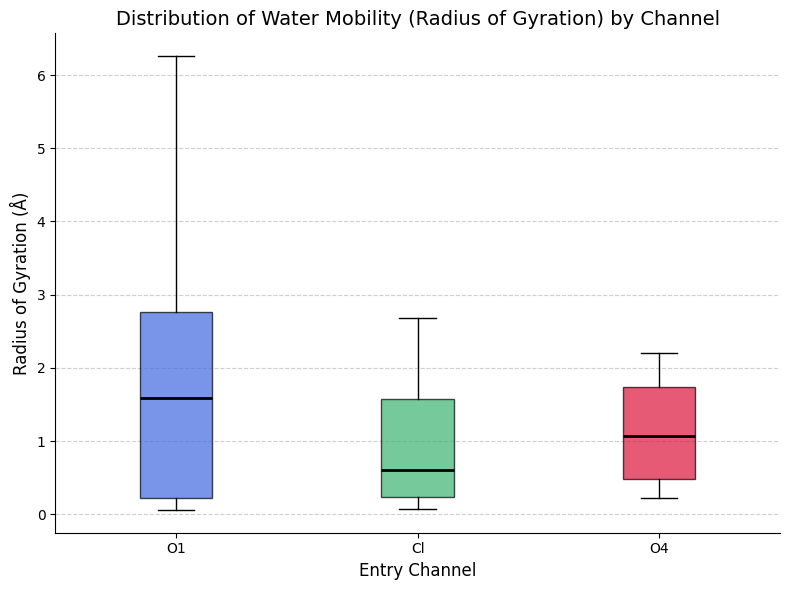

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Group Rg values by Entry Channel
channel_rgs = {'O1': [], 'Cl': [], 'O4': []}

for md_idx in exit_matches.keys():
    entry_res = entry_matches[md_idx]['resSeq']
    entry_chan = ref_waters[entry_res]['channel']
    
    rg_val = water_rg.get(md_idx, 0.0)
    
    # We only care about waters that actually moved (Rg > 0)
    if rg_val > 0:
        channel_rgs[entry_chan].append(rg_val)

# 2. Print Statistical Summary
print(f"{'Channel':<10} | {'Count':<8} | {'Mean Rg (Å)':<15} | {'Median Rg (Å)':<15} | {'Max Rg (Å)':<15}")
print("-" * 70)

for chan in ['O1', 'Cl', 'O4']:
    rgs = channel_rgs[chan]
    if rgs:
        print(f"{chan:<10} | {len(rgs):<8} | {np.mean(rgs):<15.3f} | {np.median(rgs):<15.3f} | {np.max(rgs):<15.3f}")
    else:
        print(f"{chan:<10} | {'0':<8} | {'N/A':<15} | {'N/A':<15} | {'N/A':<15}")

# 3. Generate Boxplot for Visual Comparison
fig, ax = plt.subplots(figsize=(8, 6))

data_to_plot = [channel_rgs['O1'], channel_rgs['Cl'], channel_rgs['O4']]
labels = ['O1', 'Cl', 'O4']
colors = ['royalblue', 'mediumseagreen', 'crimson']

# Create the boxplot
bplot = ax.boxplot(data_to_plot, patch_artist=True, labels=labels, 
                   medianprops=dict(color='black', linewidth=2),
                   flierprops=dict(marker='o', markerfacecolor='gray', alpha=0.5))

# Color the boxes
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Formatting
ax.set_title("Distribution of Water Mobility (Radius of Gyration) by Channel", fontsize=14)
ax.set_ylabel("Radius of Gyration (Å)", fontsize=12)
ax.set_xlabel("Entry Channel", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Starting from first frame

Parsing starting frame /Users/kanishkkondaka/Desktop/margaret_files/nvt_50ns.pdb for entry coordinates...
Scanning /Users/kanishkkondaka/Desktop/margaret_files/contacts_margaret_50_to_100.txt for final exit coordinates...
Matching Entry waters strictly to the 50ns PDB...
  -> 89 waters matched an Entry site at exactly 50ns.
Matching Exit waters from final contacts instance...
  -> 60 waters strictly matched an Exit site (Stayed or Crossed).
  -> 29 waters escaped into bulk solvent (assigned Exit = 0).

--- ALL TRACKED WATERS SUMMARY ---


,MD Water ID,Entry Res,Entry Channel,Exit Res,Exit Channel,Traj Rg (Å)
0,628432,W59,Cl,W41,Cl,2.676
1,692362,W40,Cl,W61,Cl,2.625
2,628396,W22,Cl,W59,Cl,2.437
3,434884,W21,Cl,W22,Cl,2.215
4,434992,W60,Cl,W41,Cl,2.180
...,...,...,...,...,...,...
84,434869,W19,O4,W19,O4,0.228
85,434956,W48,O4,W49,O4,0.220
86,412675,W73,O4,0,Escaped to Solvent,0.000
87,435034,W73,O4,0,Escaped to Solvent,0.000


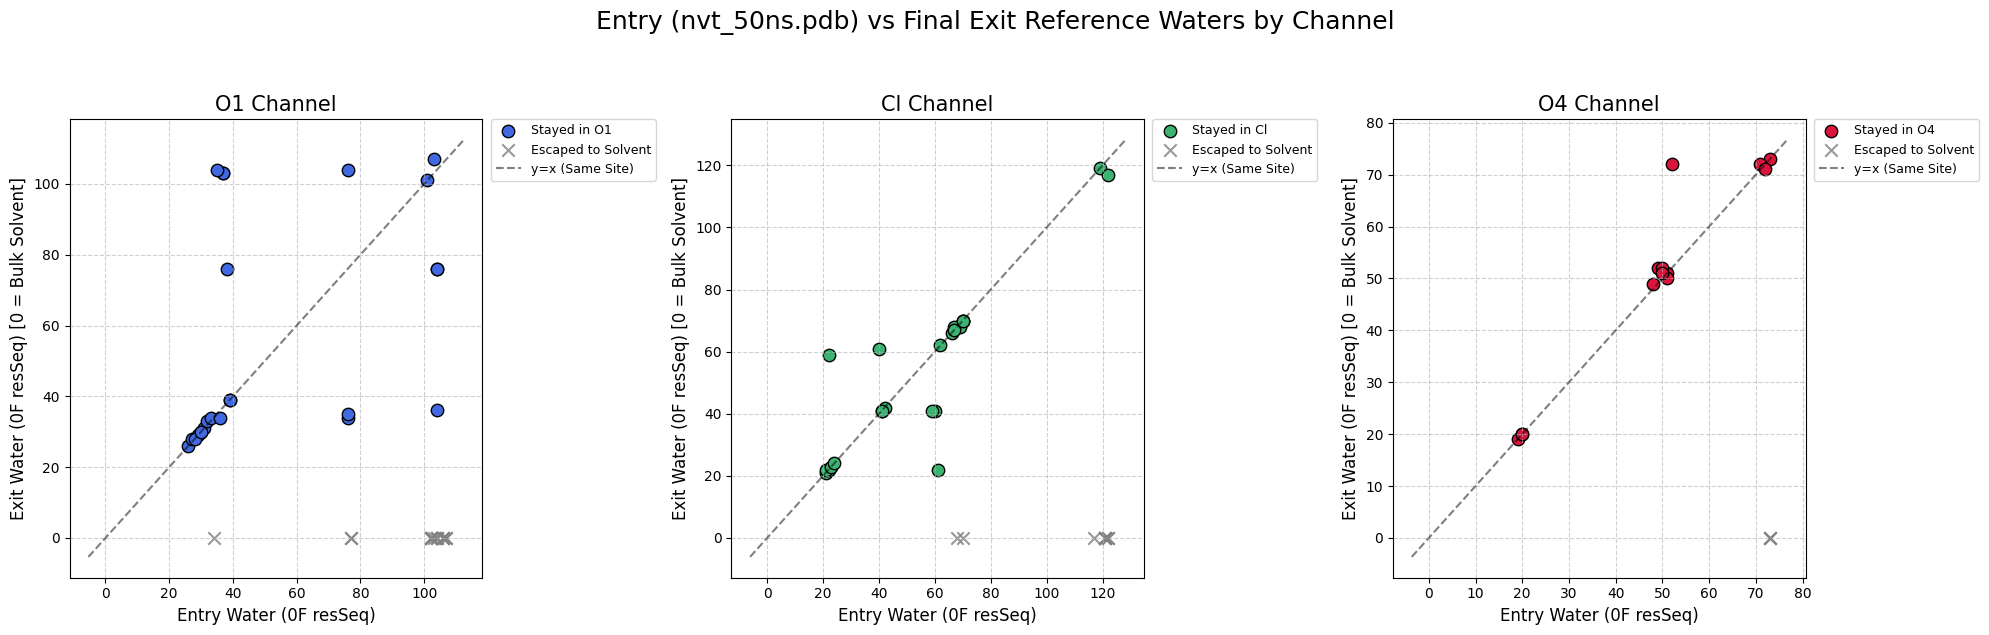

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict

# --- 1. Parse NVT 50ns PDB for Strict Entry Coordinates ---
print(f"Parsing starting frame {TARGET_PDB} for entry coordinates...")
pdb_entry_coords = {}
global_atom_index = 0  

with open(TARGET_PDB, 'r') as f:
    for line in f:
        if line.startswith("HETATM") or line.startswith("ATOM"):
            atom_name = line[12:16].strip()
            if atom_name == "OW":
                try:
                    x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
                    pdb_entry_coords[str(global_atom_index)] = (x, y, z)
                except ValueError:
                    pass
            global_atom_index += 1

# --- 2. Parse Contacts File for Final Exit Coordinates ---
print(f"Scanning {CONTACTS_FILE} for final exit coordinates...")
contacts_last_coords = {}
max_t2_tracker = defaultdict(lambda: float('-inf'))

with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if not line[0].isdigit():
            continue
            
        parts = line.strip().split()
        if len(parts) >= 6:
            w_idx = parts[0]
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            t2 = int(parts[5])
            
            # Track only the final known position in the channel
            if t2 > max_t2_tracker[w_idx]:
                max_t2_tracker[w_idx] = t2
                contacts_last_coords[w_idx] = (x, y, z)

# --- 3. Strict Entry Matching (nvt_50ns.pdb ONLY) ---
print("Matching Entry waters strictly to the 50ns PDB...")
entry_matches = {}

# Only evaluate waters that eventually have trajectory data in the contacts file
for w_idx in contacts_last_coords.keys():
    if w_idx in pdb_entry_coords:
        pdb_coord = pdb_entry_coords[w_idx]
        min_dist = float('inf')
        best_resSeq = None
        
        for resSeq, ref_data in ref_waters.items():
            dist = calc_distance(ref_data['coords'], pdb_coord)
            if dist < min_dist:
                min_dist, best_resSeq = dist, resSeq
                
        # Must be strictly within 4.0 Angstroms at t=0
        if best_resSeq is not None and min_dist <= 4.0:
            entry_matches[w_idx] = {'resSeq': best_resSeq, 'dist': min_dist}

print(f"  -> {len(entry_matches)} waters matched an Entry site at exactly 50ns.")

# --- 4. Exit Matching (With "0" Fallback for escaped waters) ---
print("Matching Exit waters from final contacts instance...")
matched_exit_coords = {w_idx: contacts_last_coords[w_idx] for w_idx in entry_matches.keys()}

strict_exit_matches = nearest_match(ref_waters, matched_exit_coords, distance_cutoff=4.0)

exit_matches = {}
for w_idx in entry_matches.keys():
    if w_idx in strict_exit_matches:
        exit_matches[w_idx] = strict_exit_matches[w_idx]
    else:
        # If it drifted out of the 4.0 Å radius by its final frame, assign it a 0
        exit_matches[w_idx] = {'resSeq': 0, 'dist': float('inf')}

print(f"  -> {len(strict_exit_matches)} waters strictly matched an Exit site (Stayed or Crossed).")
print(f"  -> {len(entry_matches) - len(strict_exit_matches)} waters escaped into bulk solvent (assigned Exit = 0).")

# ==============================================================================
# --- 5. GENERATE PANDAS DATAFRAME FOR ALL MATCHES ---
# ==============================================================================
table_data = []

for md_idx in entry_matches.keys():
    entry_res = entry_matches[md_idx]['resSeq']
    exit_res = exit_matches[md_idx]['resSeq']
    
    entry_chan = ref_waters[entry_res]['channel']
    
    if exit_res == 0:
        exit_chan_display = "Escaped to Solvent"
    else:
        exit_chan_raw = ref_waters[exit_res]['channel']
        if exit_chan_raw != entry_chan:
            exit_chan_display = f"Crossed to {exit_chan_raw}"
        else:
            exit_chan_display = exit_chan_raw
            
    rg_val = water_rg.get(md_idx, 0.0)
    
    table_data.append({
        "MD Water ID": md_idx,
        "Entry Res": f"W{entry_res}",
        "Entry Channel": entry_chan,
        "Exit Res": f"W{exit_res}" if exit_res != 0 else "0",
        "Exit Channel": exit_chan_display,
        "Traj Rg (Å)": round(rg_val, 3)
    })

df_all_matches = pd.DataFrame(table_data)
if not df_all_matches.empty:
    df_all_matches = df_all_matches.sort_values(by=["Entry Channel", "Traj Rg (Å)"], ascending=[True, False]).reset_index(drop=True)

print("\n--- ALL TRACKED WATERS SUMMARY ---")
display(df_all_matches)

# ==============================================================================
# --- 6. GENERATE 3-PANEL GRAPH ---
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Entry (nvt_50ns.pdb) vs Final Exit Reference Waters by Channel", fontsize=18, y=1.05)

colors = {'O1': 'royalblue', 'Cl': 'mediumseagreen', 'O4': 'crimson'}
channels = ["O1", "Cl", "O4"]

for ax, current_channel in zip(axes, channels):
    stay_data = {'x': [], 'y': [], 'high_x': [], 'high_y': []}
    escaped_data = {'x': [], 'y': [], 'high_x': [], 'high_y': []}
    cross_data = defaultdict(lambda: {'x': [], 'y': [], 'high_x': [], 'high_y': []})
    all_x, all_y = [], []
    
    for md_idx in entry_matches.keys():
        entry_res = entry_matches[md_idx]['resSeq']
        exit_res = exit_matches[md_idx]['resSeq']
        entry_channel = ref_waters[entry_res]['channel']
        
        if entry_channel == current_channel:
            exit_channel = ref_waters[exit_res]['channel'] if exit_res != 0 else "Escaped"
            rg_val = water_rg.get(md_idx, 0.0)
            is_high = rg_val > RG_THRESHOLD
            
            all_x.append(entry_res)
            all_y.append(exit_res)
            
            if exit_channel == current_channel:
                target = stay_data
            elif exit_channel == "Escaped":
                target = escaped_data
            else:
                target = cross_data[exit_channel]
                
            if is_high:
                target['high_x'].append(entry_res)
                target['high_y'].append(exit_res)
            else:
                target['x'].append(entry_res)
                target['y'].append(exit_res)

    if not all_x:
        ax.set_title(f"{current_channel} Channel (No Data)", fontsize=14)
        continue
        
    # 1. Plot Stayed Waters (CIRCLES)
    if stay_data['x']:
        ax.scatter(stay_data['x'], stay_data['y'], c=colors[current_channel], alpha=1.0, edgecolors='k', s=80, label=f"Stayed in {current_channel}")
    if stay_data['high_x']:
        ax.scatter(stay_data['high_x'], stay_data['high_y'], c=colors[current_channel], alpha=1.0, edgecolors='gold', linewidths=2.5, s=130, label=f"Stayed (Rg > 5.0 Å)")

    # 2. Plot Escaped Waters (CROSSES 'X' on x-axis)
    if escaped_data['x']:
        ax.scatter(escaped_data['x'], escaped_data['y'], c='gray', marker='x', alpha=0.8, s=80, label="Escaped to Solvent")
    if escaped_data['high_x']:
        ax.scatter(escaped_data['high_x'], escaped_data['high_y'], c='black', marker='X', alpha=1.0, s=130, label="Escaped (Rg > 5.0 Å)")

    # 3. Plot Crossed Waters (TRIANGLES '^')
    for dest_chan, data in cross_data.items():
        if data['x']:
            ax.scatter(data['x'], data['y'], c=colors.get(dest_chan, 'orange'), marker='^', alpha=1.0, edgecolors='k', s=100, label=f"Crossed to {dest_chan}")
        if data['high_x']:
            ax.scatter(data['high_x'], data['high_y'], c=colors.get(dest_chan, 'orange'), marker='^', alpha=1.0, edgecolors='gold', linewidths=2.5, s=150, label=f"Crossed to {dest_chan} (Rg > 5.0 Å)")

    ax.set_title(f"{current_channel} Channel", fontsize=15)
    ax.set_xlabel("Entry Water (0F resSeq)", fontsize=12)
    ax.set_ylabel("Exit Water (0F resSeq) [0 = Bulk Solvent]", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    min_val, max_val = min(all_x + all_y), max(all_x + all_y)
    pad = (max_val - min_val) * 0.05 if max_val != min_val else 5
    ax.plot([min_val - pad, max_val + pad], [min_val - pad, max_val + pad], 'k--', alpha=0.5, label='y=x (Same Site)')
    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()

In [ ]:

matched_ref_resSeqs = set(data['resSeq'] for data in entry_matches.values())

# 2. Find the difference between all available reference waters and the matched ones
unmatched_ref_resSeqs = set(ref_waters.keys()) - matched_ref_resSeqs

# 3. Group the unmatched waters by channel
unmatched_by_channel = {'O1': [], 'Cl': [], 'O4': []}
for resSeq in unmatched_ref_resSeqs:
    chan = ref_waters[resSeq]['channel']
    unmatched_by_channel[chan].append(resSeq)

# 4. Print the results
total_unmatched = 0
for chan, res_list in unmatched_by_channel.items():
    res_list.sort()
    total_unmatched += len(res_list)
    if res_list:
        print(f"{chan:<2} Channel ({len(res_list):<2} unmatched): {res_list}")
    else:
        print(f"{chan:<2} Channel (0 unmatched): All reference waters were filled!")

print("-" * 60)
print(f"Total unmatched reference waters: {total_unmatched} / {len(ref_waters)}")

O1 Channel (0 unmatched): All reference waters were filled!
Cl Channel (1  unmatched): [25]
O4 Channel (1  unmatched): [53]
------------------------------------------------------------
Total unmatched reference waters: 2 / 54


In [ ]:
import pandas as pd


# Temporarily set max_rows to None to prevent truncation
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_all_matches)


--- ALL TRACKED WATERS SUMMARY (FULL TABLE) ---


,MD Water ID,Entry Res,Entry Channel,Exit Res,Exit Channel,Traj Rg (Å)
0,628432,W59,Cl,W41,Cl,2.676
1,692362,W40,Cl,W61,Cl,2.625
2,628396,W22,Cl,W59,Cl,2.437
3,434884,W21,Cl,W22,Cl,2.215
4,434992,W60,Cl,W41,Cl,2.180
5,435022,W70,Cl,W70,Cl,1.610
6,434881,W61,Cl,W22,Cl,1.469
7,435013,W67,Cl,W68,Cl,1.461
8,692365,W41,Cl,W41,Cl,1.418
9,412201,W70,Cl,W70,Cl,0.662


In [ ]:
# --- Configuration ---
RG_THRESHOLD = 5.0  # Threshold in Angstroms for high mobility

print(f"{'='*100}")
print(f"WATERS WITH HIGH MOBILITY (Rg > {RG_THRESHOLD} Å) OR CHANNEL CROSSOVERS")
print(f"{'='*100}")

# Table headers
header = f"{'MD Water ID':<15} | {'Entry (Chan)':<16} | {'Exit (Chan)':<16} | {'Traj Rg (Å)':<12} | {'Flag Reason'}"
print(header)
print("-" * len(header))

flagged_count = 0
total_waters = len(entry_matches)

for md_idx in entry_matches.keys():
    # Retrieve matching data
    entry_res = entry_matches[md_idx]['resSeq']
    exit_res = exit_matches[md_idx]['resSeq']
    
    entry_chan = ref_waters[entry_res]['channel']
    
    # Handle the "Escaped" 0 fallback
    if exit_res != 0:
        exit_chan = ref_waters[exit_res]['channel']
    else:
        exit_chan = "Escaped"
        
    rg_val = water_rg.get(md_idx, 0.0)
    
    # Evaluate conditions (Ignore "Escaped" as a crossover, but keep it if Rg is high)
    crossed_channel = (entry_chan != exit_chan) and (exit_res != 0)
    high_rg = (rg_val > RG_THRESHOLD)
    
    # Output if flagged
    if crossed_channel or high_rg:
        flagged_count += 1
        
        reasons = []
        if crossed_channel:
            reasons.append(f"Crossed ({entry_chan} -> {exit_chan})")
        if high_rg:
            reasons.append(f"High Rg ({rg_val:.2f} Å)")
            
        reason_str = " & ".join(reasons)
        
        entry_str = f"W{entry_res} ({entry_chan})"
        exit_str = f"W{exit_res} ({exit_chan})" if exit_res != 0 else "Escaped"
        
        print(f"{md_idx:<15} | {entry_str:<16} | {exit_str:<16} | {rg_val:<12.3f} | {reason_str}")

print(f"Total flagged waters: {flagged_count} / {total_waters}")

WATERS WITH HIGH MOBILITY (Rg > 5.0 Å) OR CHANNEL CROSSOVERS
MD Water ID     | Entry (Chan)     | Exit (Chan)      | Traj Rg (Å)  | Flag Reason
----------------------------------------------------------------------------------
----------------------------------------------------------------------------------
Total flagged waters: 0 / 89


### Tracking Channel Shifts

In [ ]:
from collections import defaultdict

water_timelines = defaultdict(list)

# 1. Gather every recorded position and time for every water molecule
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if not line[0].isdigit():
            continue
        parts = line.strip().split()
        if len(parts) >= 6:
            w_idx = parts[0]
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            t1, t2 = int(parts[4]), int(parts[5])
            water_timelines[w_idx].append({
                'coords': (x, y, z),
                't1': t1,
                't2': t2
            })

header = f"{'MD Water ID':<15} | {'Switch Time (Frame)':<20} | {'Crossover Event'}"


switch_count = 0

# 2. Sort each water's timeline chronologically and check for channel changes
for w_idx, events in water_timelines.items():
    # Sort chronologically by the start time of the contact (t1)
    events.sort(key=lambda e: e['t1'])
    
    current_channel = None
    
    for event in events:
        min_dist = float('inf')
        best_chan = None
        
        # Find which channel the water is in at this exact moment
        for resSeq, ref_data in ref_waters.items():
            dist = calc_distance(ref_data['coords'], event['coords'])
            if dist < min_dist:
                min_dist = dist
                best_chan = ref_data['channel']
        
        # Only evaluate if it is strictly inside a channel (<= 4.0 Å)
        if min_dist <= 4.0:
            # If we were previously in a channel, and this one is DIFFERENT, it's a switch!
            if current_channel is not None and current_channel != best_chan:
                print(f"{w_idx:<15} | t = {event['t1']:<16} | {current_channel} -> {best_chan}")
                switch_count += 1
            
            # Update the tracker to the current channel
            current_channel = best_chan
        else:

            current_channel = None 

print("-" * len(header))
print(f"Total channel switch events detected: {switch_count}")

Analyzing timelines for channel crossovers...

MD Water ID     | Switch Time (Frame)  | Crossover Event
--------------------------------------------------------
643804          | t = 4654             | Cl -> O1
643804          | t = 5247             | O1 -> Cl
--------------------------------------------------------
Total channel switch events detected: 2


### Pymol Generation

In [ ]:
import pickle
import os
import pandas as pd

# --- Configuration ---
RG_THRESHOLD = 5.0
PICKLE_FILE = "/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/flagged_waters_data.pkl"

flagged_waters_data = []
flagged_water_ids = set() 

# 1. Grab unique water IDs and their exact paths from df_switches
intermediate_switch_ids = set()
intermediate_paths = {}

if 'df_switches' in locals() and not df_switches.empty:
    # Ensure IDs are strings
    df_switches["MD Water ID"] = df_switches["MD Water ID"].astype(str)
    intermediate_switch_ids = set(df_switches["MD Water ID"])
    
    # Map out the exact journey (e.g., "O1 -> O2 -> O3") to save in our flagged data
    for w_id, group in df_switches.groupby("MD Water ID"):
        path = list(group["From Channel"]) + [group["To Channel"].iloc[-1]]
        intermediate_paths[str(w_id)] = " -> ".join(map(str, path))

# 2. Create a master list of ALL water IDs (Union of exit_matches and df_switches)
# This guarantees we don't miss a water even if it was dropped from exit_matches
exit_match_string_keys = {str(k): k for k in exit_matches.keys()}
all_target_ids = set(exit_match_string_keys.keys()).union(intermediate_switch_ids)

# 3. Gather the data
for md_idx_str in all_target_ids:
    
    # Safely get the original key type (int or str) to look up in the original dictionaries
    orig_key = exit_match_string_keys.get(md_idx_str, md_idx_str)
    if orig_key not in exit_matches and md_idx_str.isdigit():
        if int(md_idx_str) in exit_matches:
            orig_key = int(md_idx_str)

    # Safely fetch entry/exit data (fallback to 0 if it only exists in intermediate_switches)
    entry_res = entry_matches[orig_key]['resSeq'] if orig_key in entry_matches else 0
    exit_res = exit_matches[orig_key]['resSeq'] if orig_key in exit_matches else 0
    
    entry_chan = ref_waters.get(entry_res, {'channel': 'Escaped'})['channel'] if entry_res != 0 else 'Unknown'
    exit_chan = ref_waters.get(exit_res, {'channel': 'Escaped'})['channel'] if exit_res != 0 else 'Unknown'
    
    # Safely get Rg using either int or string key
    rg_val = water_rg.get(orig_key, water_rg.get(md_idx_str, 0.0))
    
    # Define our FOUR flag conditions
    escaped_channel = (exit_chan == 'Escaped')
    crossed_channel = (entry_chan != exit_chan) and not escaped_channel
    had_intermediate_switch = (md_idx_str in intermediate_switch_ids)
    high_rg = (rg_val > RG_THRESHOLD)
    
    # Flag the water if it meets ANY of the conditions
    if escaped_channel or crossed_channel or high_rg or had_intermediate_switch:
        reasons = []
        
        if escaped_channel:
            reasons.append(f"Escaped ({entry_chan} -> Bulk/Escaped)")
        elif crossed_channel:
            reasons.append(f"Crossed ({entry_chan} -> {exit_chan})")
            
        if had_intermediate_switch:
            reasons.append("Intermediate Crossover(s)")
            
        if high_rg:
            reasons.append(f"High Rg ({rg_val:.2f} Å)")
            
        # Store as a dictionary, NOW INCLUDING THE INTERMEDIATE PATH!
        data_dict = {
            'md_water_id': md_idx_str,
            'entry_res': entry_res,
            'entry_chan': entry_chan,
            'exit_res': exit_res,
            'exit_chan': exit_chan,
            'traj_rg': rg_val,
            'intermediate_path': intermediate_paths.get(md_idx_str, "None"),  # <--- Added this!
            'flag_reason': " & ".join(reasons)
        }
        
        flagged_waters_data.append(data_dict)
        flagged_water_ids.add(md_idx_str)

# 4. Preview and Export
# Convert to a DataFrame just to display it beautifully in Jupyter before saving
final_df = pd.DataFrame(flagged_waters_data)
display(final_df.head(15))

with open(PICKLE_FILE, 'wb') as f:
    pickle.dump(flagged_waters_data, f)

print(f"Successfully saved {len(flagged_waters_data)} flagged waters to {PICKLE_FILE}")

,md_water_id,entry_res,entry_chan,exit_res,exit_chan,traj_rg,intermediate_path,flag_reason
0,844167,121,Cl,0,Unknown,0.0,None,Crossed (Cl -> Unknown)
1,555406,102,O1,0,Unknown,0.0,None,Crossed (O1 -> Unknown)
2,747796,102,O1,0,Unknown,0.0,None,Crossed (O1 -> Unknown)
3,622456,102,O1,0,Unknown,0.0,None,Crossed (O1 -> Unknown)
4,836046,73,O4,0,Unknown,0.0,None,Crossed (O4 -> Unknown)
5,589927,106,O1,0,Unknown,0.0,None,Crossed (O1 -> Unknown)
6,698527,77,O1,0,Unknown,0.0,None,Crossed (O1 -> Unknown)
7,643804,0,Unknown,0,Unknown,0.0,Cl -> O1 -> Cl,Intermediate Crossover(s)
8,713383,102,O1,0,Unknown,0.0,None,Crossed (O1 -> Unknown)
9,698524,103,O1,0,Unknown,0.0,None,Crossed (O1 -> Unknown)


Successfully saved 33 flagged waters to /Users/kanishkkondaka/Desktop/margaret_files/flagged_waters_data.pkl


In [ ]:
import os
from collections import defaultdict

# --- Configuration ---
CONTACTS_FILE = "/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/contacts_low_res_50_to_100.txt"
OUTPUT_DIR = "/Users/kanishkkondaka/Desktop/Lab_Files/low_restraint_kinetic_analysis/waters_of_interest"

# Create the output directory if it doesn't already exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

def calc_b_factor(t1, t2):
    """
    Easily editable formula for the B-factor column.
    Currently set to t2 - t1 (the duration of the contact).
    """
    return float(t2 - t1)

def batch_extract_trajectories(contacts_file, target_ids_set, output_dir):
    if not target_ids_set:
        print("No target IDs provided. Skipping extraction.")
        return
        
    occurrences_dict = defaultdict(list)
    
    print(f"Scanning {contacts_file} for {len(target_ids_set)} waters of interest...")
    
    # 1. Read and extract data in a single pass
    with open(contacts_file, 'r') as f:
        for line in f:
            if not line[0].isdigit():
                continue
                
            parts = line.strip().split()
            if len(parts) >= 6:
                w_idx = parts[0]
                
                # Check if this water is in our flagged set
                if w_idx in target_ids_set:
                    x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                    t1, t2 = int(parts[4]), int(parts[5])
                    occurrences_dict[w_idx].append((t1, t2, x, y, z))
                    
    # 2. Sort and write to PDB for each water
    print(f"Writing PDB files to {output_dir}...")
    
    for w_idx, occurrences in occurrences_dict.items():
        # Sort chronologically by t1
        occurrences.sort(key=lambda item: item[0])
        
        output_filename = os.path.join(output_dir, f"water_{w_idx}_trajectory.pdb")
        
        with open(output_filename, 'w') as out_f:
            for idx, (t1, t2, x, y, z) in enumerate(occurrences, start=1):
                
                b_factor = calc_b_factor(t1, t2)
                safe_serial = idx % 100000
                
                out_f.write(
                    f"HETATM{safe_serial:5d}  O   HOH W{safe_serial:4d}    "
                    f"{x:8.3f}{y:8.3f}{z:8.3f}  1.00{b_factor:6.2f}           O\n"
                )
            out_f.write("END\n")
            
    print(f"Done! Successfully generated {len(occurrences_dict)} PDB files.")

# Execute the batch function using the set from Cell 1
batch_extract_trajectories(CONTACTS_FILE, flagged_water_ids, OUTPUT_DIR)

Scanning /Users/kanishkkondaka/Desktop/margaret_files/contacts_margaret_50_to_100.txt for 33 waters of interest...
Writing PDB files to /Users/kanishkkondaka/Desktop/margaret_files/waters_of_interest...
Done! Successfully generated 33 PDB files.


## RMSD of Channels

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
#  Configuration
# ============================================================
CONTACTS_FILE = "contacts_low_res_50_to_100.txt"
CAVER_PDB     = "/Users/yyklab/Downloads/O4.pdb"  # Update this to your caver channel PDB
CHANNEL_NAME  = "O4"

# CAVER profiles often define the void space. You may need to add the 
# radius of a water molecule (~1.4 Å) to the caver sphere radius to accurately 
# capture the center of oxygen atoms touching the channel boundary.
WATER_PROBE_RADIUS = 1.4 

# ============================================================
# 1. Load the Caver Channel Profile
# ============================================================
def load_caver_spheres(pdb_filename):

    spheres = []
    with open(pdb_filename, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                x = float(line[30:38].strip())
                y = float(line[38:46].strip())
                z = float(line[46:54].strip())
                # Radius is typically in the B-factor column
                r = float(line[60:66].strip()) 
                spheres.append([x, y, z, r])
    return np.array(spheres)

caver_spheres = load_caver_spheres(CAVER_PDB)

# ============================================================
# 2. Parse Contacts and Find "Inside" Waters
# ============================================================
water_ids = []
coords = []

# Read all contact coordinates into memory
with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if line[0].isdigit():
            parts = line.strip().split()
            if len(parts) >= 4:
                # We extract the water id and its x, y, z coordinates[cite: 2]
                widx = int(parts[0])
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                
                water_ids.append(widx)
                coords.append([x, y, z])

water_ids = np.array(water_ids)
coords = np.array(coords)

print(" {len(coords)} total contacts")

inside_mask = np.zeros(len(coords), dtype=bool)

for cx, cy, cz, r in caver_spheres:
    # Calculate squared distance to avoid expensive square root operations
    dist_sq = (coords[:, 0] - cx)**2 + (coords[:, 1] - cy)**2 + (coords[:, 2] - cz)**2
    # Check if inside this specific sphere's radius
    effective_radius = r + WATER_PROBE_RADIUS
    inside_mask |= (dist_sq <= effective_radius**2)

# Filter arrays to only keep points strictly inside the Caver volume
inside_wids = water_ids[inside_mask]
inside_coords = coords[inside_mask]
print(f"Found {len(inside_coords)} waters in {CHANNEL_NAME}")

# ============================================================
# 3. Calculate RMSD for Each Water 
# ============================================================
# Group the inside-channel coordinates by water index
water_points = defaultdict(list)
for wid, coord in zip(inside_wids, inside_coords):
    water_points[wid].append(coord)

rmsd_values = []
valid_waters = []

for wid, pts in water_points.items():
    pts_array = np.array(pts)
    
    # We need at least 2 points inside the channel to calculate a meaningful RMSD
    if len(pts_array) >= 2:
        # 1. Find the centroid (mean position) of the water while in the channel
        centroid = pts_array.mean(axis=0)
        
        # 2. Calculate RMS deviation from that centroid
        # RMSD = sqrt( mean( sum( (points - centroid)^2 ) ) )
        rmsd = np.sqrt(np.mean(np.sum((pts_array - centroid)**2, axis=1)))
        
        rmsd_values.append(rmsd)
        valid_waters.append(wid)

rmsd_values = np.array(rmsd_values)

if len(rmsd_values) == 0:
    print("Error: Not enough data points fell inside the channel to calculate RMSD.")
else:
    avg_rmsd = rmsd_values.mean()
    print(f"\nRMSD for {len(rmsd_values)} distinct water molecules.")
    print(f"Average RMSD for {CHANNEL_NAME} waters: {avg_rmsd:.2f} Å")
    
    # Identify extreme behaviors
    order = np.argsort(rmsd_values)
    print(f"Lowest-RMSD (most confined) water:  ID {valid_waters[order[0]]} ({rmsd_values[order[0]]:.2f} Å)")
    print(f"Highest-RMSD (most mobile) water:   ID {valid_waters[order[-1]]} ({rmsd_values[order[-1]]:.2f} Å)")

    # ============================================================
    # 4. Plot Histogram
    # ============================================================
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # Generate bins dynamically based on the maximum RMSD
    bins = np.arange(0, np.ceil(rmsd_values.max()) + .5, 0.5)
    
    ax.hist(rmsd_values, bins=bins, color="royalblue", edgecolor="white", alpha=0.8)
    
    ax.set_xlabel("RMS deviation from mean position (Å)", fontsize=12)
    ax.set_ylabel("Number of Water Molecules", fontsize=12)
    ax.set_title(f"Average RMSD for waters inside the {CHANNEL_NAME} channel: {avg_rmsd:.2f} Å", fontsize=14)
    
    # Clean up aesthetics
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    output_filename = f"RMSD_hist_{CHANNEL_NAME}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nSaved histogram to: {output_filename}")
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yyklab/Downloads/O4.pdb'

### Histogram of Time Spent

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
#  Configuration
# ============================================================
CONTACTS_FILE = "contacts_margaret_50_to_100.txt"
CAVER_PDB     = "/Users/yyklab/Downloads/O4.pdb"  
CHANNEL_NAME  = "O4"

# 1.4 Å represents the approximate radius of a water molecule
WATER_PROBE_RADIUS = 1.4 

# Time conversion: based on your previous code, 1 frame = 2.0 ps.
# 2.0 ps = 0.002 ns.
DT_NS = 0.002 

# ============================================================
# 1. Load the Caver Channel Profile
# ============================================================
def load_caver_spheres(pdb_filename):
    spheres = []
    with open(pdb_filename, 'r') as f:
        for line in f:
            if line.startswith("ATOM") or line.startswith("HETATM"):
                x = float(line[30:38].strip())
                y = float(line[38:46].strip())
                z = float(line[46:54].strip())
                r = float(line[60:66].strip()) 
                spheres.append([x, y, z, r])
    return np.array(spheres)

caver_spheres = load_caver_spheres(CAVER_PDB)

# ============================================================
# 2. Parse Contacts and Find "Inside" Waters
# ============================================================
water_ids = []
coords = []
durations = []

with open(CONTACTS_FILE, 'r') as f:
    for line in f:
        if line[0].isdigit():
            parts = line.strip().split()
            if len(parts) >= 6:
                widx = int(parts[0])
                x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
                t1 = int(parts[4]) # t_start[cite: 2]
                t2 = int(parts[5]) # ts-1[cite: 2]
                
                water_ids.append(widx)
                coords.append([x, y, z])
                
                # Calculate the duration of this specific contact episode in frames
                durations.append(t2 - t1)

water_ids = np.array(water_ids)
coords = np.array(coords)
durations = np.array(durations)

print(f" {len(coords)} total contacts")

# Vectorized spatial inclusion check
inside_mask = np.zeros(len(coords), dtype=bool)

for cx, cy, cz, r in caver_spheres:
    dist_sq = (coords[:, 0] - cx)**2 + (coords[:, 1] - cy)**2 + (coords[:, 2] - cz)**2
    effective_radius = r + WATER_PROBE_RADIUS
    inside_mask |= (dist_sq <= effective_radius**2)

# Filter arrays to only keep episodes strictly inside the Caver volume
inside_wids = water_ids[inside_mask]
inside_durations = durations[inside_mask]

# ============================================================
# 3. Calculate Total Time Spent per Unique Water
# ============================================================
# A single water might bounce around and have multiple contact episodes 
# inside the channel. We want to sum the total time spent per unique water ID.
total_frames_per_water = defaultdict(int)

for wid, duration in zip(inside_wids, inside_durations):
    total_frames_per_water[wid] += duration

# Convert frames to nanoseconds
times_ns = []
for wid, total_frames in total_frames_per_water.items():
    times_ns.append(total_frames * DT_NS)

times_ns = np.array(times_ns)

if len(times_ns) == 0:
    print(f"Error: No waters found inside the {CHANNEL_NAME} channel.")
else:
    avg_time = times_ns.mean()
    max_time = times_ns.max()
    
    print(f"\nCalculated residence times for {len(times_ns)} distinct water molecules.")
    print(f"Average time spent in {CHANNEL_NAME}: {avg_time:.3f} ns")
    print(f"Maximum time spent in {CHANNEL_NAME}: {max_time:.3f} ns")

    # ============================================================
    # 4. Plot Histogram
    # ============================================================
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Create bins. Adjust the step size (0.5 ns) if your data range is very small or very large
    bin_width = 0.2 
    bins = np.arange(0, np.ceil(max_time) + bin_width, bin_width)
    
    ax.hist(times_ns, bins=bins, color="mediumseagreen", edgecolor="white", alpha=0.8)
    
    ax.set_xlabel("Total Time Spent in Channel (ns)", fontsize=12)
    ax.set_ylabel("Number of Water Molecules", fontsize=12)
    ax.set_title(f"Residence Time Distribution in the {CHANNEL_NAME} Channel (50-100 ns)", fontsize=14)
    
    # Add a vertical line showing the average time
    ax.axvline(avg_time, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {avg_time:.2f} ns')
    ax.legend()
    
    # Clean up aesthetics
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    output_filename = f"Residence_Time_hist_{CHANNEL_NAME}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\n {output_filename}")
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yyklab/Downloads/O4.pdb'